# Lending Club Case Study

## Business Understanding

Lending club is a consumer finance company specialises in lending various loans to urban customers. Company provides fast online interface through which borrowers can easily apply and get access to lower interest rate loans. This company is the largest online loan marketplace, facilitating personal loans, business loans, and financing of medical procedures.

On receiving a loan application company has to make a deceion for loan approval based on the applicant's profile. Two types of decisions that could be taken by the company:

**Loan accepted:** If the company approves the loan, there are 3 possible scenarios described below:

**1. Fully paid:** Applicant has fully paid the loan (the principal and the interest rate)

**2. Current:** Applicant is in the process of paying the instalments, i.e. the tenure of the loan is not yet completed. These candidates are not labelled as 'defaulted'.

**3. Charged-off:** Applicant has not paid the instalments in due time for a long period of time, i.e. Borrower has defaulted on the loan 

**Loan rejected:** The company had rejected the loan (because the candidate does not meet their requirements etc.). Since the loan was rejected, there is no transactional history of those applicants with the company and so this data is not available with the company.

     
 ## Business Objectives

Like most other lending companies, lending loans to ‘risky’ applicants is the largest source of financial loss (called credit loss). The credit loss is the amount of money lost by the lender when the borrower refuses to pay or runs away with the money owed. In other words, borrowers who default cause the largest amount of loss to the lenders. In this case, the customers labelled as 'charged-off' are the 'defaulters'. 
If one is able to identify these risky loan applicants, then such loans can be reduced thereby cutting down the amount of credit loss. The company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilise this knowledge for its portfolio and risk assessment. 

## Exploratory Data Analysis

Inputs : Lending Club has provided us the private data for all loans issued through the time period 2007 to 2011.
Company has also give us the data dictionary which describes the meaning of these variables.

Investors : Company has graded each loan request. Investor can look through the borrows information in the loan details and decide which loan listing to invest in.
Only those variables be chosen for analysis that will be available to the investor at the time of deciding whether to invest in a loan request or not.

### Data Understanding

In [1]:
# Importing all required python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# formatting for float values
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_rows', 60)
sns.set(style='whitegrid')


In [3]:
# Loading loan.csv file into 'loan' dataframes
loan = pd.read_csv('loan.csv', encoding = "ISO-8859-1", low_memory=False)

In [4]:
#  loan dataframe has 39717 rows and 111 columns
loan.shape

(39717, 111)

In [5]:
# understanding the data : column names, null values and primary keys, etc. 
loan.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.00,36 months,10.65%,162.87,B,B2,...,nan,nan,nan,nan,0.00,0.00,nan,nan,nan,nan
1,1077430,1314167,2500,2500,2500.00,60 months,15.27%,59.83,C,C4,...,nan,nan,nan,nan,0.00,0.00,nan,nan,nan,nan
2,1077175,1313524,2400,2400,2400.00,36 months,15.96%,84.33,C,C5,...,nan,nan,nan,nan,0.00,0.00,nan,nan,nan,nan
3,1076863,1277178,10000,10000,10000.00,36 months,13.49%,339.31,C,C1,...,nan,nan,nan,nan,0.00,0.00,nan,nan,nan,nan
4,1075358,1311748,3000,3000,3000.00,60 months,12.69%,67.79,B,B5,...,nan,nan,nan,nan,0.00,0.00,nan,nan,nan,nan


In [6]:
# understanding the data of various columns
loan.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,39717.00,39717.00,39717.00,39717.00,39717.00,39717.00,39717.00,39717.00,39717.00,39717.00,...,0.00,0.00,0.00,0.00,39020.00,39678.00,0.00,0.00,0.00,0.00
mean,683131.91,850463.56,11219.44,10947.71,10397.45,324.56,68968.93,13.32,0.15,0.87,...,nan,nan,nan,nan,0.04,0.00,nan,nan,nan,nan
std,210694.13,265678.31,7456.67,7187.24,7128.45,208.87,63793.77,6.68,0.49,1.07,...,nan,nan,nan,nan,0.20,0.00,nan,nan,nan,nan
min,54734.00,70699.00,500.00,500.00,0.00,15.69,4000.00,0.00,0.00,0.00,...,nan,nan,nan,nan,0.00,0.00,nan,nan,nan,nan
25%,516221.00,666780.00,5500.00,5400.00,5000.00,167.02,40404.00,8.17,0.00,0.00,...,nan,nan,nan,nan,0.00,0.00,nan,nan,nan,nan
50%,665665.00,850812.00,10000.00,9600.00,8975.00,280.22,59000.00,13.40,0.00,1.00,...,nan,nan,nan,nan,0.00,0.00,nan,nan,nan,nan
75%,837755.00,1047339.00,15000.00,15000.00,14400.00,430.78,82300.00,18.60,0.00,1.00,...,nan,nan,nan,nan,0.00,0.00,nan,nan,nan,nan
max,1077501.00,1314167.00,35000.00,35000.00,35000.00,1305.19,6000000.00,29.99,11.00,8.00,...,nan,nan,nan,nan,2.00,0.00,nan,nan,nan,nan


In [7]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 33.6+ MB


In [8]:
# understanding the datatype of various columns.
loan.dtypes

id                              int64
member_id                       int64
loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv               float64
                               ...   
tax_liens                     float64
tot_hi_cred_lim               float64
total_bal_ex_mort             float64
total_bc_limit                float64
total_il_high_credit_limit    float64
Length: 111, dtype: object

In [9]:
# Lets check null values counts in loan data. 
loan.isnull().sum()

id                                0
member_id                         0
loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
                              ...  
tax_liens                        39
tot_hi_cred_lim               39717
total_bal_ex_mort             39717
total_bc_limit                39717
total_il_high_credit_limit    39717
Length: 111, dtype: int64

## Data Cleaning



In [10]:
# Expressing missing values in each columns in interms of %
round(loan.isnull().sum()/len(loan.index), 2)*100

id                             0.00
member_id                      0.00
loan_amnt                      0.00
funded_amnt                    0.00
funded_amnt_inv                0.00
                              ...  
tax_liens                      0.00
tot_hi_cred_lim              100.00
total_bal_ex_mort            100.00
total_bc_limit               100.00
total_il_high_credit_limit   100.00
Length: 111, dtype: float64

In [11]:
# Expressing missing values in each columns in interms of %
missing_columns = round((loan.isnull().sum()/len(loan.id)*100), 2)
missing_columns.loc[missing_columns > 0]

emp_title                      6.19
emp_length                     2.71
desc                          32.58
title                          0.03
mths_since_last_delinq        64.66
                              ...  
tax_liens                      0.10
tot_hi_cred_lim              100.00
total_bal_ex_mort            100.00
total_bc_limit               100.00
total_il_high_credit_limit   100.00
Length: 68, dtype: float64

As above we can notice many columns have 100% values are missing and we can also see 'desc' column is missing 32.58% and 'mths_since_last_delinq' is missing 64.66% data missing.

In [12]:
# removing the columns having more than 60% missing values
missing_columns = loan.columns[100*(loan.isnull().sum()/len(loan.index)) > 60]
print(missing_columns)

Index(['mths_since_last_delinq', 'mths_since_last_record', 'next_pymnt_d',
       'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint',
       'verification_status_joint', 'tot_coll_amt', 'tot_cur_bal',
       'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
       'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m',
       'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi',
       'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal',
       'bc_open_to_buy', 'bc_util', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_t

In [13]:
len(missing_columns)

57

We can notice about 57 columns which are above 60% missing values.

In [14]:
# Removing 57 columns which are more than 60% missing values.
loan = loan.drop(missing_columns,axis=1)
loan.shape

(39717, 54)

In [15]:
(loan.isnull().sum()/len(loan.index))*100

id                            0.00
member_id                     0.00
loan_amnt                     0.00
funded_amnt                   0.00
funded_amnt_inv               0.00
term                          0.00
int_rate                      0.00
installment                   0.00
grade                         0.00
sub_grade                     0.00
emp_title                     6.19
emp_length                    2.71
home_ownership                0.00
annual_inc                    0.00
verification_status           0.00
issue_d                       0.00
loan_status                   0.00
pymnt_plan                    0.00
url                           0.00
desc                         32.58
purpose                       0.00
title                         0.03
zip_code                      0.00
addr_state                    0.00
dti                           0.00
delinq_2yrs                   0.00
earliest_cr_line              0.00
inq_last_6mths                0.00
open_acc            

In [16]:
missing_columns = round((loan.isnull().sum()/len(loan.id)*100), 2)
missing_columns.loc[missing_columns > 0]

emp_title                     6.19
emp_length                    2.71
desc                         32.58
title                         0.03
revol_util                    0.13
last_pymnt_d                  0.18
last_credit_pull_d            0.01
collections_12_mths_ex_med    0.14
chargeoff_within_12_mths      0.14
pub_rec_bankruptcies          1.75
tax_liens                     0.10
dtype: float64

#### The columns which still have missing values are : 

'emp_title', 'emp_length', 'revol_util', 'last_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'pub_rec_bankruptcies', 'tax_liens'.

**desc** : Loan description provided by the borrower. The 'desc' is long description about the borrower, the relevant consise information also present in the 'purpose' and 'title' columns. We can safely remove desc column.

In [17]:
loan = loan.drop('desc',axis=1)

**emp_length** : Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 
**emp_title** : The job title supplied by the Borrower when applying for the loan.

Columns emp_title = 6.19% and emp_length = 2.71% missing value. As these two columns have important data related to borrows, let's clean/remove the rows with nan/blank values.

In [18]:
loan.emp_title.unique()

array([nan, 'Ryder', 'AIR RESOURCES BOARD', ..., 'FiSite Research',
       'Squarewave Solutions, Ltd.', 'Evergreen Center'], dtype=object)

In [19]:
loan.emp_length.unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [20]:
loan=loan[~loan.emp_title.isnull()]
loan=loan[~loan.emp_length.isnull()]

In [21]:
missing_columns = round((loan.isnull().sum()/len(loan.id)*100), 2)
missing_columns.loc[missing_columns > 0]

title                        0.02
revol_util                   0.12
last_pymnt_d                 0.17
collections_12_mths_ex_med   0.13
chargeoff_within_12_mths     0.13
pub_rec_bankruptcies         1.76
tax_liens                    0.09
dtype: float64

In [22]:
loan.shape

(37202, 53)

**title** :The loan title provided by the borrower.

**revol_util** :Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.

**last_pymnt_d**:Last month payment was received

These have very small % of missing value of 0.03%, 0.13% and 0.18% respectively. Let's clean/remove the rows with nan/blank values.

In [23]:
loan=loan[~loan.title.isnull()]
loan=loan[~loan.revol_util.isnull()]
loan=loan[~loan.last_pymnt_d.isnull()]

In [24]:
missing_columns = round((loan.isnull().sum()/len(loan.id)*100), 2)
missing_columns.loc[missing_columns > 0]

collections_12_mths_ex_med   0.13
chargeoff_within_12_mths     0.13
pub_rec_bankruptcies         1.76
tax_liens                    0.09
dtype: float64

In [25]:
pd.DataFrame(loan, columns=['chargeoff_within_12_mths','collections_12_mths_ex_med','tax_liens']).apply(pd.Series.unique)

,chargeoff_within_12_mths,collections_12_mths_ex_med,tax_liens
0,0.00,0.00,0.00
1,nan,nan,nan


In [26]:
loan.collections_12_mths_ex_med.unique()

array([ 0., nan])

In [27]:
loan.chargeoff_within_12_mths.unique()

array([ 0., nan])

In [28]:
loan.pub_rec_bankruptcies.unique()

array([ 0.,  1.,  2., nan])

In [29]:
loan.tax_liens.unique()

array([ 0., nan])

**collections_12_mths_ex_med**: Number of collections in 12 months excluding medical collections

**chargeoff_within_12_mths**: Number of charge-offs within 12 months

**tax_liens**: Number of tax liens

The columns 'collections_12_mths_ex_med', 'chargeoff_within_12_mths' and 'tax_liens' has either value of '0.' or 'nan'. By analysing these columns we can colclude the values these columns take are of not much significance to our analysis.Hence, we are going to drop these columns.

In [30]:
drop_columnlist = ['collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'tax_liens']
loan = loan.drop(drop_columnlist,axis=1)

In [31]:
missing = round(100*(loan.isnull().sum()/len(loan.id)), 2)
missing[missing != 0]

pub_rec_bankruptcies   1.76
dtype: float64

In [32]:
loan.shape

(37087, 50)

In [33]:
loan.pub_rec_bankruptcies.value_counts()

0.00    34931
1.00     1495
2.00        7
Name: pub_rec_bankruptcies, dtype: int64

**No bankrupcies** : 0

**First time bankrupcies** : 34931

**Second time bankrupcies** : 7

After analysing 'bankrupcies' columns, we can either impute the 0 values with the some values. As our analysis is for identifying the defaulters we decide to remove the rows with value 0 bankrupcies.

In [34]:
loan=loan[~loan.pub_rec_bankruptcies.isnull()]

In [35]:
missing = round(100*(loan.isnull().sum()/len(loan.id)), 2)
missing[missing != 0]

Series([], dtype: float64)

In [36]:
loan.shape

(36433, 50)

After cleaning up missing values, we arrive at data with 36433 rows and 50 columns, we can save it into another file for incase we need it for future analysis.

In [37]:
loan.to_csv('loan_data_cleaned.csv', encoding='utf-8', index=False)

Continuing column investigation and dropping the columns which doesn't provide any value to our analysis.

In [38]:
cleaned_loan_df = loan[:]

In [39]:
cleaned_loan_df.shape

(36433, 50)

In [40]:
cleaned_loan_df.nunique().sort_values()

acc_now_delinq                 1
application_type               1
policy_code                    1
initial_list_status            1
delinq_amnt                    1
pymnt_plan                     1
term                           2
pub_rec_bankruptcies           3
loan_status                    3
verification_status            3
home_ownership                 4
pub_rec                        5
grade                          7
inq_last_6mths                 9
delinq_2yrs                   11
emp_length                    11
purpose                       14
sub_grade                     35
open_acc                      38
addr_state                    49
issue_d                       52
total_acc                     79
last_credit_pull_d            96
last_pymnt_d                  97
int_rate                     334
earliest_cr_line             510
zip_code                     806
loan_amnt                    863
funded_amnt                 1024
out_prncp                   1064
out_prncp_

A data dictionary file is provided along with the loan data. This file gives a brief describtion about all the columns of the loan transaction file.

After analysing this file and understanding we see few columns Single unique value or all unique values.These columns doesn't provide any help to our analysis of loan default. **We are dropping these column from dataframe.**

**acc_now_delinq**: The value of this entire data set is 0 hence we can remove it.

**application_type**: It contains entire dataset value as 'INDIVIDUAL', since all are indivisual applications. In Home loan we have an option of joint loan. Seems like Lending club does't provide option of joint loan.
This column doesn't contribute for analysis, so we can removem it.

**policy_code**: The value for this column for entire dataset is '1', indicating all are publicly available, this column doesn't contribute for analysis, so we can removem it.

**initial_list_status**: The value for entire dataset is 'f' out of the possible values, therefore can be removed.


**delinq_amnt**: This column contains entire dataset as '0', we can remove it.

**pymnt_plan**: The value for entire dataset is 'n', this column doesn't contribute for analysis, so we can removem it.

**funded_amnt**: Value for this column is almost similar to loan_amnt. We can remove this column.

**zip_code**: We have addr_state column which provides the state info, we can remove this column.

**funded_amnt_inv**: Similar value also found in funded_amnt, we can remove this column.

**url**: Its a LC URL for corresponding to each memberid, it doesn't provide any value to loan default analysis. we can remove this column.

**member_id**: Its a random number generated for each member, it doesn't provide any value to loan default analysis. we can remove this column.

**id**: Its a random number given for each member, it doesn't provide any value to loan default analysis. we can remove this column.

Few more columns which are not much helpful in our loan default analysis, hence dropping those columns.


In [41]:
columns_to_dropped = ['acc_now_delinq','application_type','policy_code','initial_list_status','delinq_amnt','pymnt_plan','funded_amnt','zip_code','funded_amnt_inv','url','member_id','id','title','inq_last_6mths','out_prncp','out_prncp_inv','total_pymnt_inv','total_rec_prncp','total_rec_int','total_rec_late_fee','recoveries','collection_recovery_fee','last_pymnt_amnt','last_credit_pull_d','total_acc'] 
cleaned_loan_df= cleaned_loan_df.drop(columns_to_dropped,axis=1)

In [42]:
cleaned_loan_df.shape


(36433, 25)

In [43]:
cleaned_loan_df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_pymnt', 'last_pymnt_d',
       'pub_rec_bankruptcies'],
      dtype='object')

Next, there are few columns which denote date or month information but are of the type object in the dataframe. Let's change the dtype of all such columns to datetime. Doing so will help in further using these column values to its best for analysis.
These columns are:

1. issue_d
2. earliest_cr_line
3. last_pymnt_d
4. last_credit_pull_d

In [44]:
cleaned_loan_df.issue_d.value_counts().tail()

Feb-08    6
Aug-07    2
Dec-07    2
Nov-07    1
Oct-07    1
Name: issue_d, dtype: int64

In [45]:
cleaned_loan_df.earliest_cr_line.value_counts().tail()

Feb-65    1
Dec-66    1
Feb-67    1
Feb-73    1
Dec-68    1
Name: earliest_cr_line, dtype: int64

In [46]:
cleaned_loan_df.last_pymnt_d.value_counts().tail()

Aug-08    5
Sep-08    5
Dec-08    5
Nov-08    4
Jun-08    2
Name: last_pymnt_d, dtype: int64

In [47]:
datetime_colmns=['issue_d','earliest_cr_line','last_pymnt_d']
cleaned_loan_df[datetime_colmns].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36433 entries, 1 to 39680
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   issue_d           36433 non-null  object
 1   earliest_cr_line  36433 non-null  object
 2   last_pymnt_d      36433 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


Converting the dtype of these columns to datetime



In [48]:
cleaned_loan_df.issue_d = pd.to_datetime(cleaned_loan_df.issue_d, format='%b-%y')
cleaned_loan_df.earliest_cr_line = pd.to_datetime(cleaned_loan_df.earliest_cr_line, format='%b-%y')
cleaned_loan_df.last_pymnt_d = pd.to_datetime(cleaned_loan_df.last_pymnt_d, format='%b-%y')

In [49]:
cleaned_loan_df[datetime_colmns].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36433 entries, 1 to 39680
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   issue_d           36433 non-null  datetime64[ns]
 1   earliest_cr_line  36433 non-null  datetime64[ns]
 2   last_pymnt_d      36433 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 1.1 MB


In [50]:
cleaned_loan_df.shape


(36433, 25)

In [51]:
cleaned_loan_df=cleaned_loan_df.drop_duplicates()

In [52]:
cleaned_loan_df.shape


(36433, 25)


There are few columns expressing % like int_rate and revol_util.
These has values like '15.27%' and '9.40%'.
Further these columns has dtype as 'object'. Let's convert these columns to have just the value withoout '%' and typecast it to float.

In [53]:
cleaned_loan_df.int_rate.describe()


count      36433
unique       334
top       10.99%
freq         901
Name: int_rate, dtype: object

In [54]:
cleaned_loan_df.revol_util.describe()


count     36433
unique     1082
top          0%
freq        852
Name: revol_util, dtype: object

In [55]:

cleaned_loan_df['int_rate'] = cleaned_loan_df['int_rate'].str.strip('%').astype('float')
cleaned_loan_df['revol_util'] = cleaned_loan_df['revol_util'].str.strip('%').astype('float')

In [56]:
cleaned_loan_df[['int_rate','revol_util']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36433 entries, 1 to 39680
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   int_rate    36433 non-null  float64
 1   revol_util  36433 non-null  float64
dtypes: float64(2)
memory usage: 853.9 KB


In [57]:
cleaned_loan_df.int_rate.describe()

count   36433.00
mean       12.07
std         3.73
min         5.42
25%         9.32
50%        11.86
75%        14.65
max        24.40
Name: int_rate, dtype: float64

In [58]:
cleaned_loan_df.revol_util.describe()

count   36433.00
mean       49.28
std        28.19
min         0.00
25%        26.10
50%        49.90
75%        72.70
max        99.90
Name: revol_util, dtype: float64

Let us now take a look at the emp_length column.



In [59]:
cleaned_loan_df.emp_length.value_counts()

10+ years    8407
2 years      4178
< 1 year     4052
3 years      3914
4 years      3297
5 years      3129
1 year       3026
6 years      2121
7 years      1697
8 years      1405
9 years      1207
Name: emp_length, dtype: int64


According to the data_dictionary file description for this field,
emp_length: Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.
Let's convert the column to have values between 0 and 10.

In [60]:
emp_length_dict = {
    '< 1 year' : 0,
    '1 year' : 1,
    '2 years' : 2,
    '3 years' : 3,
    '4 years' : 4,
    '5 years' : 5,
    '6 years' : 6,
    '7 years' : 7,
    '8 years' : 8,
    '9 years' : 9,
    '10+ years' : 10
}

In [61]:
cleaned_loan_df = cleaned_loan_df.replace({"emp_length": emp_length_dict })

In [62]:
cleaned_loan_df.emp_length.value_counts()

10    8407
2     4178
0     4052
3     3914
4     3297
5     3129
1     3026
6     2121
7     1697
8     1405
9     1207
Name: emp_length, dtype: int64

The column term: The number of payments on the loan. Values are in months and can be either 36 or 60.
removing the months string from within the column term.

In [63]:
cleaned_loan_df.term.value_counts()

 36 months    26377
 60 months    10056
Name: term, dtype: int64

In [64]:
cleaned_loan_df['term'] = cleaned_loan_df.term.apply(lambda x: x.split()[0])

In [65]:
cleaned_loan_df.term.value_counts()

36    26377
60    10056
Name: term, dtype: int64

In [66]:
cleaned_loan_df.earliest_cr_line.value_counts()

1998-11-01    353
1999-10-01    348
1998-12-01    327
2000-10-01    320
2000-11-01    301
             ... 
2062-11-01      1
1973-08-01      1
1969-02-01      1
1972-06-01      1
2063-01-01      1
Name: earliest_cr_line, Length: 510, dtype: int64

earliest_cr_line: The month the borrower's earliest reported credit line was opened. Let's split the date column into earliest_cr_line_month and earliest_cr_line_year

Lets split the available date into month and year column.

In [67]:
cleaned_loan_df['earliest_cr_line_month'] = cleaned_loan_df['earliest_cr_line'].dt.month
cleaned_loan_df['earliest_cr_line_year'] = cleaned_loan_df['earliest_cr_line'].dt.year

In [68]:
len(cleaned_loan_df[cleaned_loan_df['earliest_cr_line_year'] > 2011 ])

50

As we observe that there are 50 records with the earliest credit line date greater than 2011.

In [69]:
cleaned_loan_df[cleaned_loan_df['earliest_cr_line_year'] > 2011 ]['earliest_cr_line_year'].unique()

array([2068, 2067, 2065, 2063, 2066, 2062, 2056, 2046, 2050, 2064, 2054],
      dtype=int64)

Its some type error let's fix the entries.

In [70]:
cleaned_loan_df.loc[cleaned_loan_df['earliest_cr_line_year'] > 2011 , 'earliest_cr_line_year'] = cleaned_loan_df['earliest_cr_line_year'] - 100

In [71]:
cleaned_loan_df.groupby('earliest_cr_line_year').loan_amnt.count()

earliest_cr_line_year
1946       1
1950       1
1954       1
1956       1
1962       3
1963       4
1964       2
1965       6
1966       7
1967      12
1968      12
1969      22
1970      35
1971      34
1972      33
1973      41
1974      51
1975      57
1976      73
1977      90
1978     130
1979     141
1980     150
1981     154
1982     196
1983     296
1984     360
1985     406
1986     447
1987     565
1988     671
1989     781
1990     944
1991     884
1992     970
1993    1398
1994    1860
1995    1974
1996    2074
1997    2271
1998    2645
1999    2763
2000    3034
2001    2363
2002    1794
2003    1740
2004    1639
2005    1406
2006    1079
2007     668
2008     144
Name: loan_amnt, dtype: int64

**issue_d**: The month which the loan was funded . 

Lets split the date into month and year column.

In [72]:
cleaned_loan_df['issue_d_month'] = cleaned_loan_df['issue_d'].dt.month
cleaned_loan_df['issue_d_year'] = cleaned_loan_df['issue_d'].dt.year

Writing the cleanedup data to a csv, it might be useful in further analysis.

In [73]:
cleaned_loan_df.to_csv('master_loan.csv', encoding='utf-8', index=False)

In [74]:
cleaned_loan_df.shape

(36433, 29)

# Univariate and Segmented Univariate Analysis

Loading the created master data for further anaysis.

In [75]:
master_loan = cleaned_loan_df[:]

In [76]:
master_loan.shape

(36433, 29)

In [77]:
master_loan.int_rate.value_counts()

10.99    901
13.49    785
11.49    768
7.51     731
7.88     674
        ... 
11.22      1
16.33      1
18.72      1
9.83       1
17.44      1
Name: int_rate, Length: 334, dtype: int64

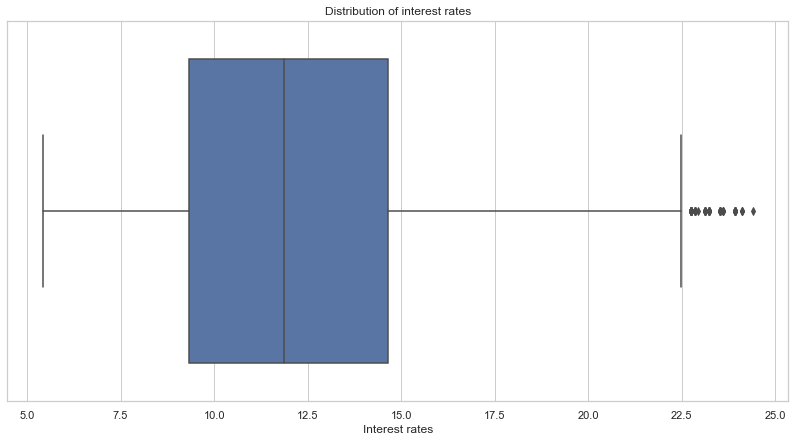

In [78]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
sns.boxplot(x='int_rate', data=master_loan)
plt.title('Distribution of interest rates')
plt.xlabel('Interest rates')
plt.show()

From **Univariate analysis on int_rate column**, we can confirm that the interest rates of most of the loans are between 9% to 14.5% and median is at around 11.5%

Outlier detection:
From the above plot we can observe that there are outliers after the right whisker. Interest rates above 22.5% are outliers.

Text(0.5, 1.0, 'Percentage of loans fully paid, charged off and current')

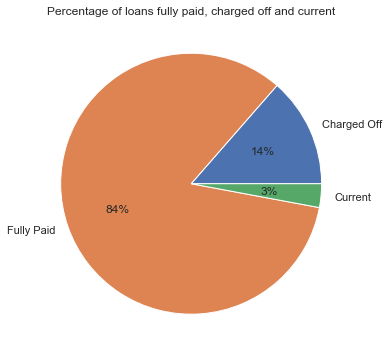

In [79]:
from itertools import chain
from collections import Counter

paid_percent = round(sum(master_loan.loan_status == 'Fully Paid')/len(loan) * 100, 2)
charged_off_percent = round(sum(master_loan.loan_status == 'Charged Off')/len(loan) * 100, 2)
current_percent = round(sum(master_loan.loan_status == 'Current')/len(loan) * 100, 2)

cts = Counter(master_loan.loan_status.unique())
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)
plt.pie([charged_off_percent,paid_percent, current_percent], labels=cts.keys(), autopct='%1.0f%%')
plt.title('Percentage of loans fully paid, charged off and current')

**Univariate analysis on loan_status column.**
Its evident from above that majority (84%) of the borrowers have fully paid the borrowed amount. About 14% of the borrowers are 'charged off' and 3% of the borrowers are currently repaying loans.

Let's continue with our analysis, whether the borrower repays the loan or defaults, we can study the patterns of borrowers who were charged off.

As our analysis to identify the differences between the borrowers who fully paid or charged off, the Current borrows doesn't provide any help here. Hence, drop "Current" data and only keep the loans with status "Fully Paid" or "Charged Off".

In [80]:
master_loan = master_loan[master_loan['loan_status'].isin(['Fully Paid','Charged Off'])]
master_loan.shape

(35367, 29)

In [81]:
master_loan.loan_status.value_counts()

Fully Paid     30424
Charged Off     4943
Name: loan_status, dtype: int64

In [82]:
master_loan.dtypes

loan_amnt                          int64
term                              object
int_rate                         float64
installment                      float64
grade                             object
sub_grade                         object
emp_title                         object
emp_length                         int64
home_ownership                    object
annual_inc                       float64
verification_status               object
issue_d                   datetime64[ns]
loan_status                       object
purpose                           object
addr_state                        object
dti                              float64
delinq_2yrs                        int64
earliest_cr_line          datetime64[ns]
open_acc                           int64
pub_rec                            int64
revol_bal                          int64
revol_util                       float64
total_pymnt                      float64
last_pymnt_d              datetime64[ns]
pub_rec_bankrupt

In [83]:
## Wonderful solution to show labels in bar plots - copied from https://stackoverflow.com/a/48372659 and edited
def showLabelsPer(ax, d=None):
    plt.margins(0.2, 0.2)
    rects = ax.patches
    i = 0
    locs, labels = plt.xticks() 
    counts = {}
    if not d is None:
        for key, value in d.items():
            counts[str(key)] = value

    # For each bar: Place a label
    for rect in rects:
        # Get X and Y placement of label from rect.
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2

        # Number of points between bar and label. Change to your liking.
        space = 5
        # Vertical alignment for positive values
        va = 'bottom'

        # If value of bar is negative: Place label below bar
        if y_value < 0:
            # Invert space to place label below
            space *= -1
            # Vertically align label at top
            va = 'top'

        # Use Y value as label and format number with one decimal place
        if d is None:
            label = "{:.1f}%".format(y_value)
        else:
            try:
                #label = "{:.1f}%".format(y_value) + "\nof " + str(counts[str(labels[i].get_text())])
                label = "{:.1f}%".format(y_value)
            except:
                label = "{:.1f}%".format(y_value)
        
        i = i+1

        # Create annotation
        plt.annotate(
            label,                      # Use `label` as label
            (x_value, y_value),         # Place label at end of the bar
            xytext=(0, space),          # Vertically shift label by `space`
            textcoords="offset points", # Interpret `xytext` as offset in points
            ha='center',                # Horizontally center label
            va=va)                      # Vertically align label differently for
                                        # positive and negative values.

In [84]:
## Wonderful solution to show labels in bar plots - copied from https://stackoverflow.com/a/48372659 and edited
def showLabelsCount(ax, d=None):
    plt.margins(0.2, 0.2)
    rects = ax.patches
    i = 0
    locs, labels = plt.xticks() 
    counts = {}
    if not d is None:
        for key, value in d.items():
            counts[str(key)] = value

    # For each bar: Place a label
    for rect in rects:
        # Get X and Y placement of label from rect.
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2

        # Number of points between bar and label. Change to your liking.
        space = 5
        # Vertical alignment for positive values
        va = 'bottom'

        # If value of bar is negative: Place label below bar
        if y_value < 0:
            # Invert space to place label below
            space *= -1
            # Vertically align label at top
            va = 'top'

        # Use Y value as label and format number with one decimal place
        if d is None:
            label = y_value
        else:
            try:
                label = str(counts[str(labels[i].get_text())]) 
            except:
                label = y_value
        
        i = i+1

        # Create annotation
        plt.annotate(
            label,                      # Use `label` as label
            (x_value, y_value),         # Place label at end of the bar
            xytext=(0, space),          # Vertically shift label by `space`
            textcoords="offset points", # Interpret `xytext` as offset in points
            ha='center',                # Horizontally center label
            va=va)                      # Vertically align label differently for
                                        # positive and negative values.

In [85]:
# This method box plot of target column against loan_status column
def plot_distribution_box(dataframe, col):
    plt.figure(figsize=(15,5))
    sns.boxplot(x=dataframe[col], y=dataframe['loan_status'], data=dataframe)
    plt.show()

In [86]:
# This function plots a given column buckets against loan_status (default = 'Charged Off')
def plotLoanStatus(dataframe, by, loanstatus='Charged Off'):
    group_count = dataframe.groupby(['loan_status',by])[by].count()
    count = dataframe.groupby(by)[by].count()
    percentages = group_count * 100 / count.T
    ax = percentages.loc[loanstatus].plot.bar(color=sns.color_palette('deep', 16))
    ax.set_ylabel('% of loans ' + loanstatus)
    showLabelsPer(ax, group_count['Charged Off'].to_dict())
    plt.margins(0.2, 0.2)
    plt.tight_layout()
    return ax

In [87]:
def plot_graphs(by,sortbyindex=False):
    plt.figure(figsize=(15, 5))
    # subplot 1:
    plt.subplot(1, 2, 1)
    grp = master_loan.groupby(['loan_status',by])[by].count()
    chart = sns.countplot(x=by,  hue="loan_status", data=master_loan)
    showLabelsCount(chart, grp['Charged Off'].to_dict())
    plt.title("Count Plot for Charged off and Fully Paid loans")

    # subplot 2:
    plt.subplot(1, 2, 2)
    plotLoanStatus(master_loan,by)    

In [88]:
master_loan.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_pymnt', 'last_pymnt_d',
       'pub_rec_bankruptcies', 'earliest_cr_line_month',
       'earliest_cr_line_year', 'issue_d_month', 'issue_d_year'],
      dtype='object')

**Variable : loan_status**

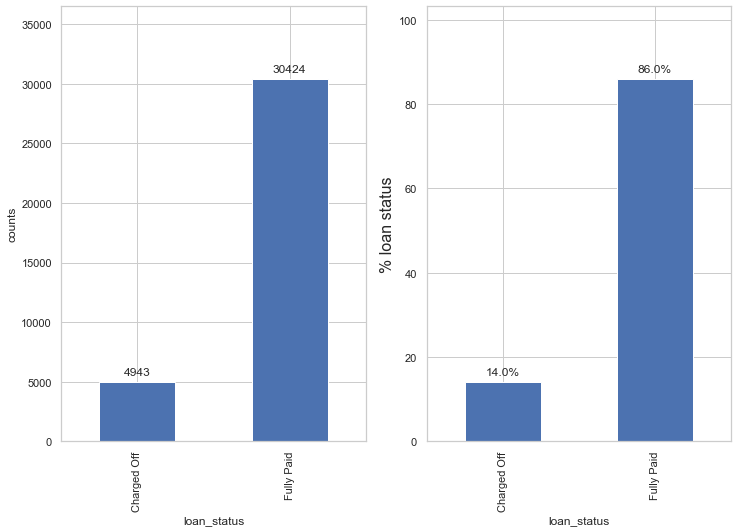

In [89]:
plt.figure(figsize=(12,8))
plt.subplot(1, 2, 1)
ax = master_loan.groupby('loan_status').loan_status.count().plot.bar()
ax.set_ylabel('counts', fontsize=12)
grp = master_loan.groupby(['loan_status'])['loan_status'].count()
showLabelsCount(ax, grp.to_dict())

plt.subplot(1, 2, 2)
ax = (master_loan.groupby('loan_status').loan_status.count() * 100 / len(master_loan.loan_status)).plot.bar()
ax.set_ylabel('% loan status', fontsize=16)
plt.margins(0.2, 0.2)
showLabelsPer(ax)
plt.show()

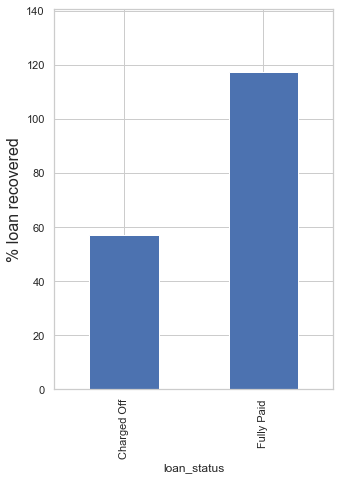

In [90]:
plt.figure(figsize=(5,7))
ax = (master_loan.groupby('loan_status').total_pymnt.sum() * 100 / master_loan.groupby('loan_status').loan_amnt.sum()).plot.bar()
ax.set_ylabel('% loan recovered', fontsize=16)

plt.margins(0.2, 0.2)

**Analysis**:
Its observed that 86% of loan is fully paid, where as Charged Off is 14%

### Variable : loan_amnt

**loan_amnt**: The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.

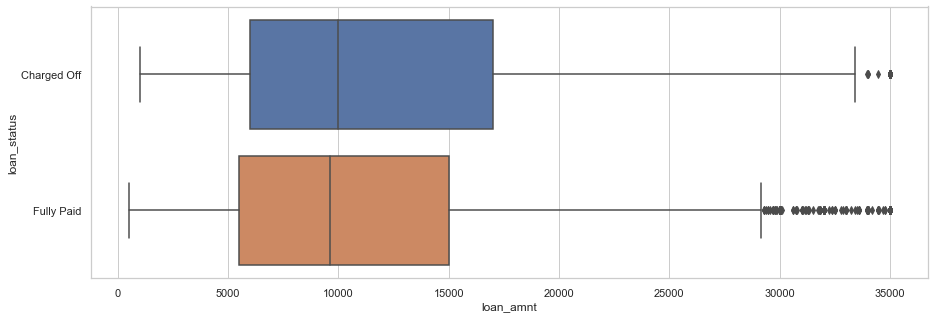

In [91]:
plot_distribution_box(master_loan, 'loan_amnt')

In [92]:
master_loan.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,4943.00,12286.15,8064.26,1000.00,6000.00,10000.00,17000.00,35000.00
Fully Paid,30424.00,10945.73,7181.87,500.00,5500.00,9600.00,15000.00,35000.00


#### Observation:
* From the boxplot we can notice the average loan amount in Charged Off are at higher side:
    * Fully Paid **mean**: 10945.73 and **median**: 9600.00
    * Charged Off **mean**: 12286.15 and **median**: 10000.00


In [93]:
#Creating derived column for the loam amount bins.
master_loan['loan_amnt_bin'] = pd.cut(master_loan['loan_amnt'], [x for x in range(0, 36000, 5000)], labels=[str(x)+'-'+str(x+5)+'k' for x in range (0, 35, 5)])

In [94]:
master_loan['loan_amnt_bin'].count()

35367

In [95]:
# Total loans across bins.
master_loan.groupby('loan_amnt_bin')['loan_amnt_bin'].count()

loan_amnt_bin
0-5k       8432
5-10k     11748
10-15k     7200
15-20k     4059
20-25k     2599
25-30k      661
30-35k      668
Name: loan_amnt_bin, dtype: int64

In [96]:
# Total loans across bins segmented by "Charged Off" and "Fully Paid".
master_loan.groupby(['loan_status','loan_amnt_bin'])['loan_amnt_bin'].value_counts()

loan_status  loan_amnt_bin  loan_amnt_bin
Charged Off  0-5k           0-5k              1095
             5-10k          5-10k             1443
             10-15k         10-15k             946
             15-20k         15-20k             687
             20-25k         20-25k             478
             25-30k         25-30k             134
             30-35k         30-35k             160
Fully Paid   0-5k           0-5k              7337
             5-10k          5-10k            10305
             10-15k         10-15k            6254
             15-20k         15-20k            3372
             20-25k         20-25k            2121
             25-30k         25-30k             527
             30-35k         30-35k             508
Name: loan_amnt_bin, dtype: int64

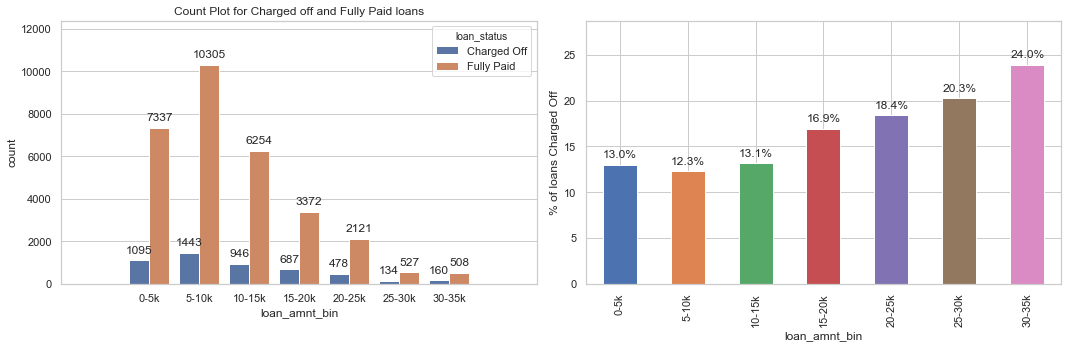

In [97]:
plot_graphs('loan_amnt_bin')

### Observation:

* From above graph and data we can infer that most of the loans were below 20K amount.
* As we notice in graph the % "Charged Off" loans continuously increasing as loan amount (loan_amnt_bin) increases.
* The loans in the bins 25-30K and 30-35K are lesser in number but potentially high chances of becoming default.

### Variable: term
**term**: The number of payments on the loan. Values are in months and can be either 36 or 60.

<Figure size 720x360 with 0 Axes>

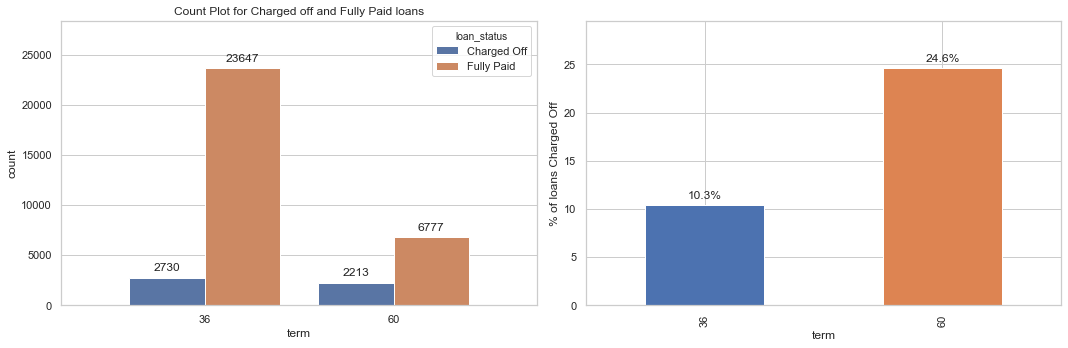

In [98]:
plt.figure(figsize=(10,5))
plot_graphs('term')

In [99]:
master_loan.loan_amnt.count()

35367

In [100]:
master_loan.loan_amnt.sum()

393743350

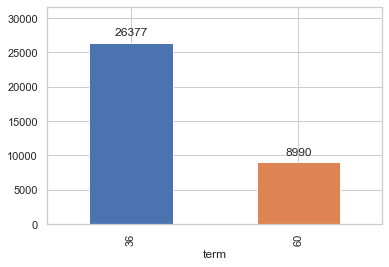

In [101]:
ax = master_loan.groupby('term').loan_amnt.count().plot.bar(color=sns.color_palette('deep', 16))
showLabelsCount(ax)

### Observation:
* We can infer that most of the loan's applied in the 36 month term.
    
* From above graphs we can infer that for 5 years tenure of loans getting "charged off" upto **24.6%**. We can see increase in "charged off" for 5 year loan tenure.

### Variable: purpose
**purpose** : A category provided by the borrower for the loan request.

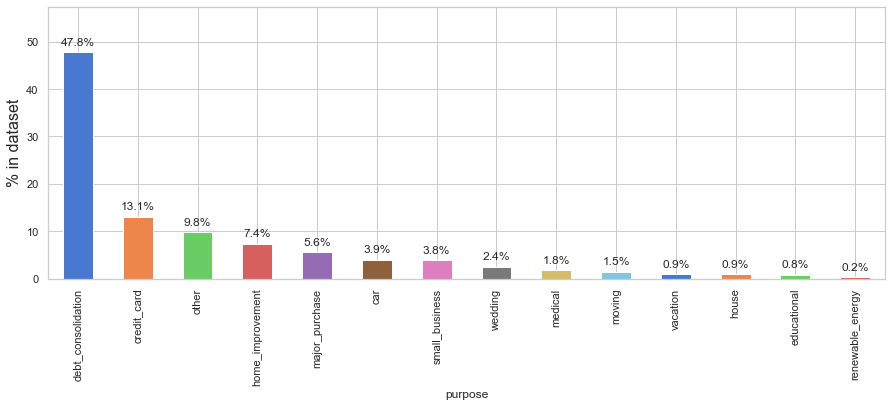

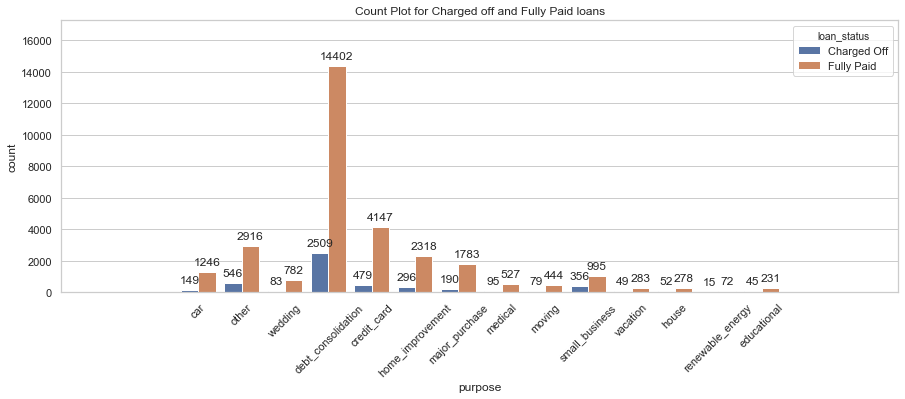

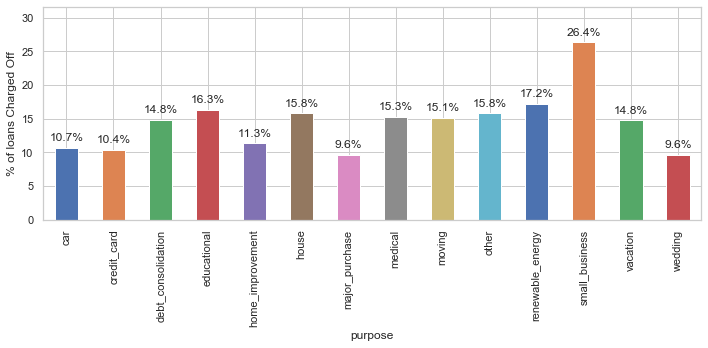

In [102]:
plt.figure(figsize=(15,5))
values = (master_loan['purpose'].value_counts(normalize=True)*100)
if False:
    values = values.sort_index()
ax = values.plot.bar(color=sns.color_palette('muted', 16))
ax.set_ylabel('% in dataset', fontsize=16)
ax.set_xlabel('purpose', fontsize=12)
showLabelsPer(ax)

#Plotting count distribution of target column purpose with respect to loan status
plt.figure(figsize=(15,5))
chart = sns.countplot(x='purpose',  hue="loan_status", data=master_loan)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45)
grp = master_loan.groupby(['loan_status','purpose'])['purpose'].count()
showLabelsCount(chart, grp['Charged Off'].to_dict())
plt.title("Count Plot for Charged off and Fully Paid loans")
plt.show()

#Plotting % of loan charged off out of each purchase bin
plt.figure(figsize=(10, 5))
plotLoanStatus(master_loan,'purpose')

 We can see highest number of loan amount issued to 'debt_consolidation'.

### Observation:

* Around **48%** of the loans are issued for the purpose of **dept_consolidation**.
* **26.4%** of the loans for **small_business** are charged Off, need to consider this while lending loan.
* **17%** of the loans for **renewable_enrgy** are charged Off, but the number is too less to be of significance.

### Variable: pub_rec_bankruptcy
**pub_rec_bankruptcy**: Number of public record bankruptcies

<Figure size 504x360 with 0 Axes>

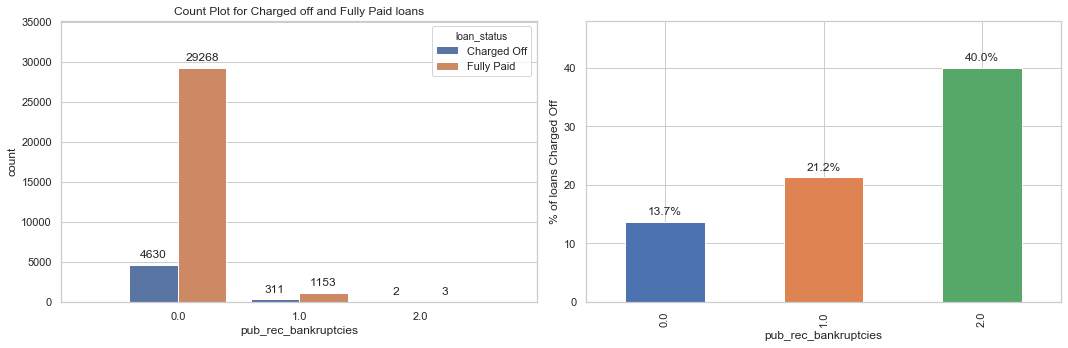

In [103]:
plt.figure(figsize=(7,5))
plot_graphs('pub_rec_bankruptcies')

### Observation:
* The % of loans "Charged Off" with previous history of bankruptcies.
    * Previous history of **One time bankrupt** are **21.2%**.
    * Previous history of **Two time bankrupt** are **40.0%**.    

### Variable: int_rate
**int_rate**: Interest Rate on the loan.

In [104]:
master_loan.int_rate.describe()

count   35367.00
mean       11.98
std         3.70
min         5.42
25%         8.94
50%        11.83
75%        14.46
max        24.40
Name: int_rate, dtype: float64

<Figure size 1080x360 with 0 Axes>

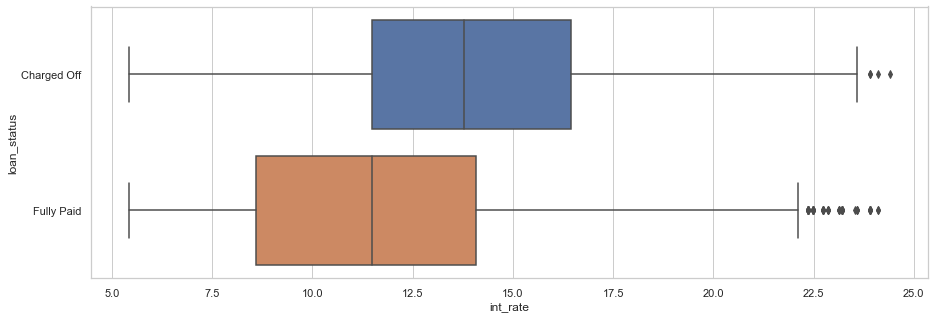

In [105]:
plt.figure(figsize=(15,5))
plot_distribution_box(master_loan, 'int_rate')

In [106]:
master_loan['interest_rate_buckets'] = round(master_loan['int_rate'])

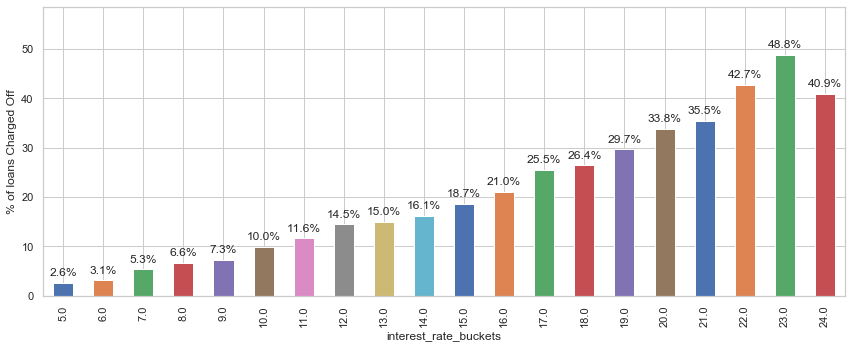

In [107]:
plt.figure(figsize=(12,5))
plotLoanStatus(master_loan, 'interest_rate_buckets')

**Observation:**

* The interest rates varies from  **5.42%** to **24.4%** with average intrest rate of 11.8%.
* The intrest rate for Charged Off loans appear to be higher than for Fully paid. 
* Its very clean from the above graph as the risk increases the rate of interest imposed on the loan also increases.

**Variable : installment** (The monthly payment owed by the borrower if the loan originates.)

In [108]:
master_loan.installment.describe()


count   35367.00
mean      324.04
std       207.15
min        16.08
25%       167.84
50%       280.62
75%       426.64
max      1305.19
Name: installment, dtype: float64

<Figure size 1080x360 with 0 Axes>

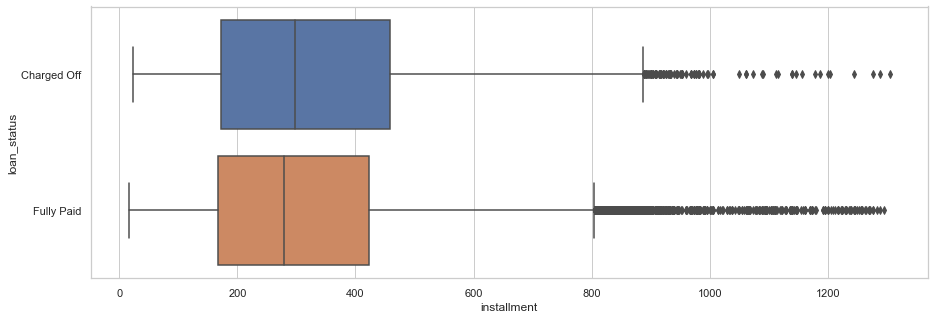

In [109]:
plt.figure(figsize=(15,5))
plot_distribution_box(master_loan, 'installment')

**Observation:**

* The Charged Off has the high installment, varies largly between 22.79 to 458.31 with median of 298.33

**Variable: grade and sub_grade** (LC assigned loan grade and subgrade.)

Let's print the value count of each grade.

In [110]:
master_loan.grade.value_counts()

B    10718
A     9140
C     7181
D     4663
E     2481
F      902
G      282
Name: grade, dtype: int64

In [111]:
master_loan.sub_grade.value_counts(normalize=True).head()

A4   0.08
B3   0.07
A5   0.07
B5   0.07
B4   0.06
Name: sub_grade, dtype: float64

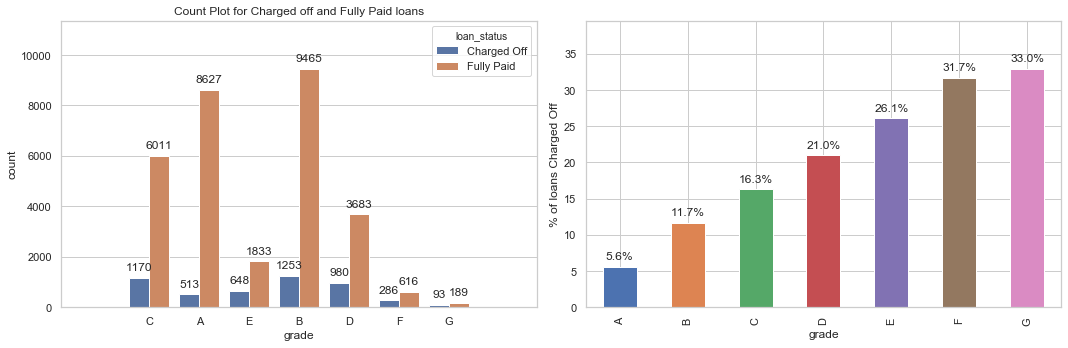

In [112]:
plot_graphs('grade')

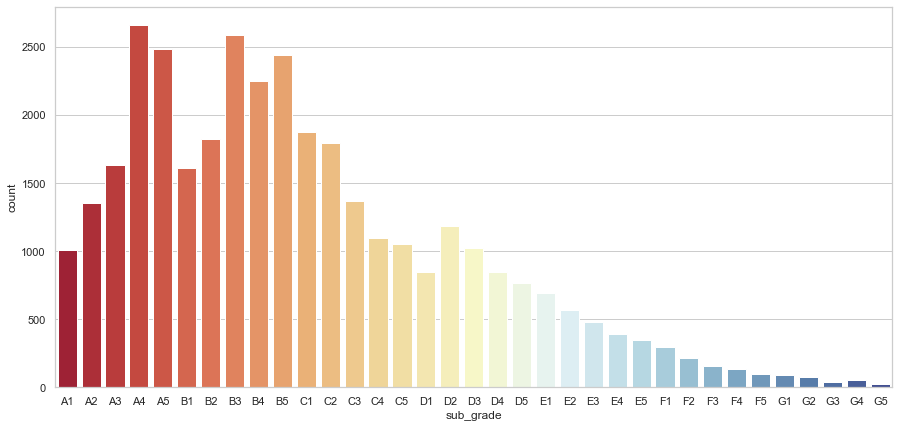

In [113]:
plt.figure(figsize=(15,7))
sns.countplot(master_loan['sub_grade'], order=sorted(master_loan.sub_grade.unique()), palette="RdYlBu")
plt.show()

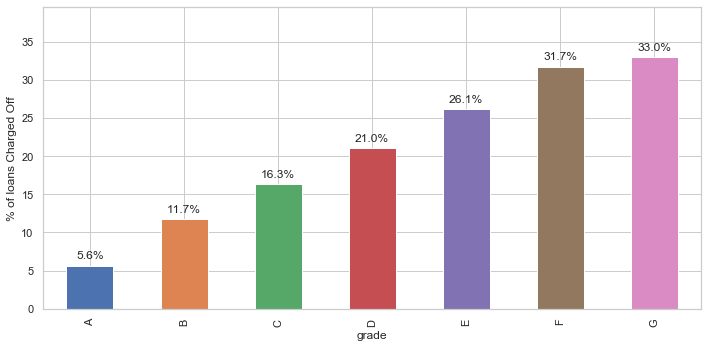

In [114]:
plt.figure(figsize=(10,5))
plotLoanStatus(master_loan, 'grade')

**Observation:**

* As we infer from graphs, the Grade A and B % in entire data set is higher than the % Charged Off loans. Grade A and B loans are safer. The Grade D, E, F, and G loans are less safe.
* About 30% of all loans in Grades F and G see a default.
* The grading system of Lending Club is working correct.

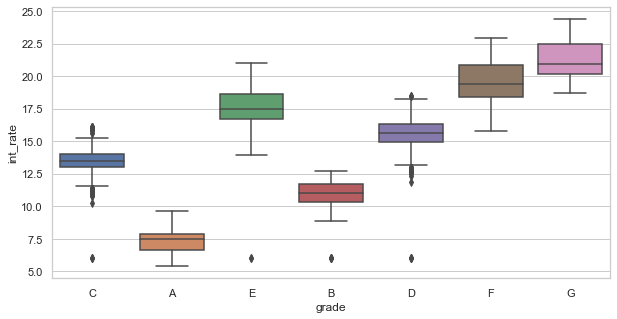

In [115]:
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(y=master_loan['int_rate'], x=master_loan['grade'], data=loan)

**Observation:**

* From above box plot we can infer that Lending Club is correctly charging **higher interest rates for lower grade loans**.

**Variable - emp_title** (The job title supplied by the Borrower when applying for the loan. Employer Title replaces Employer Name for all loans listed after 9/23/2013)

In [116]:
top10_emp_title = master_loan.emp_title.value_counts(normalize=False).head(10)
top10_emp_title

US Army              128
Bank of America      106
IBM                   65
AT&T                  57
Kaiser Permanente     55
Wells Fargo           52
USAF                  51
UPS                   51
US Air Force          50
Walmart               44
Name: emp_title, dtype: int64

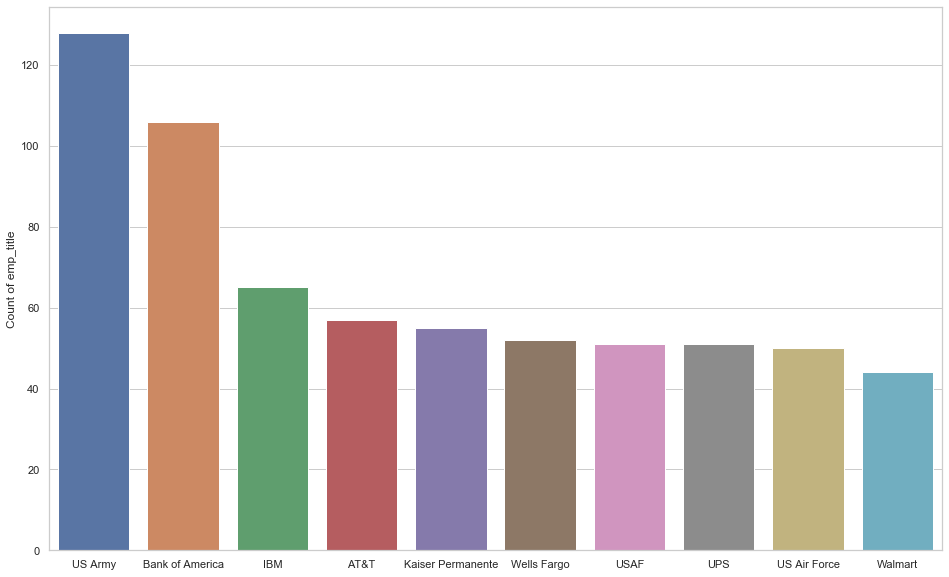

In [117]:
plt.figure(figsize=(16,10))
a=sns.barplot(x=top10_emp_title.index, y=top10_emp_title.values)
a.set_ylabel('Count of emp_title')
plt.show()

**Observation:**

* The maximum orrowers are working in US Army, Bank of America, IBM and AT&T.
* Kaiser Permanents, wells Fargo, UPS, USAF, US Air Force and Walmart are also among the top 10 emp_title loans.

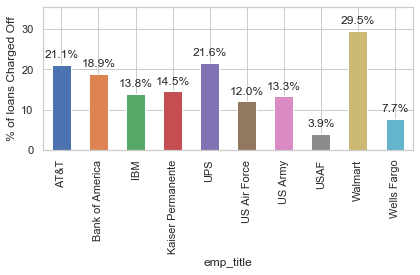

In [118]:
plotLoanStatus(master_loan[master_loan['emp_title'].isin(top10_emp_title.index.values)], 'emp_title')

**Variable - emp_length** (Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.)

In [119]:
master_loan.emp_length.value_counts(normalize=True)

10   0.23
2    0.12
0    0.11
3    0.11
4    0.09
5    0.09
1    0.08
6    0.06
7    0.05
8    0.04
9    0.03
Name: emp_length, dtype: float64

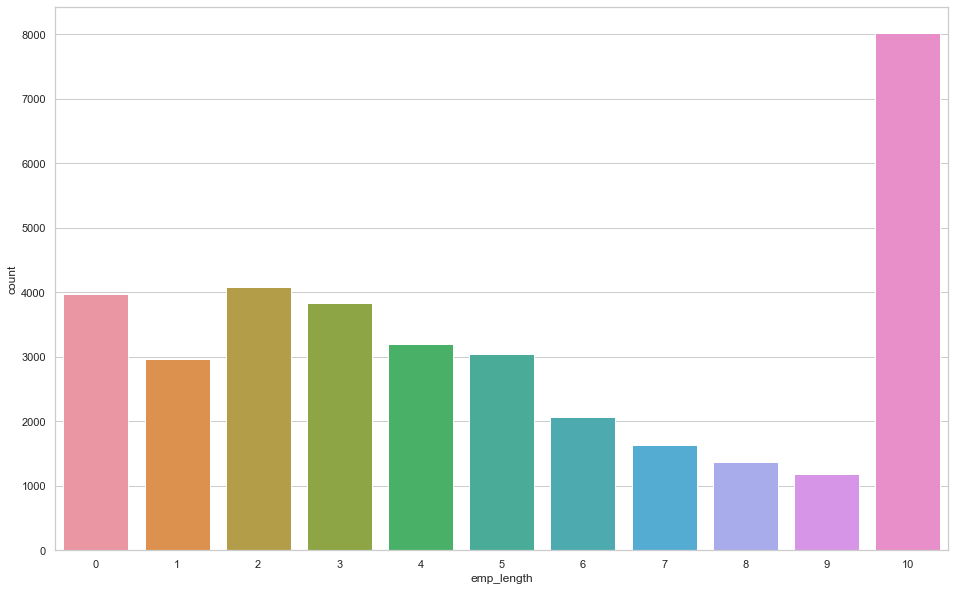

In [120]:
plt.figure(figsize=(16,10))
sns.countplot(master_loan['emp_length'], order=sorted(master_loan.emp_length.unique()))
plt.show()

<Figure size 1080x360 with 0 Axes>

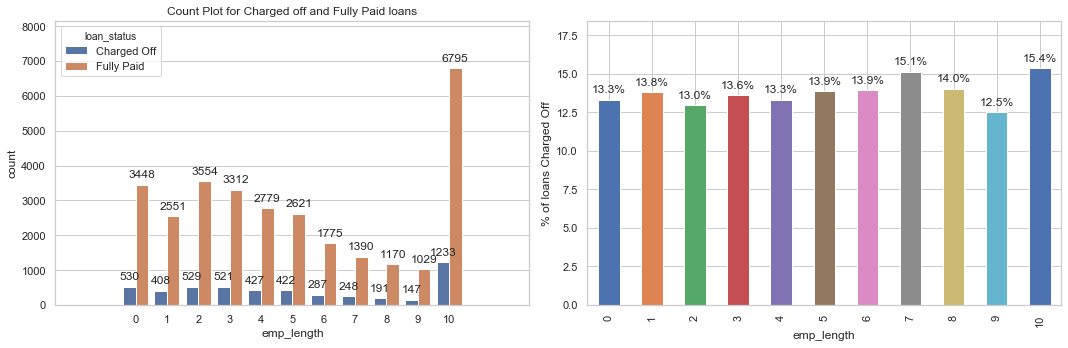

In [121]:
plt.figure(figsize=(15, 5))
plot_graphs('emp_length')

**Observation:**

* The borrowers with more than 10 years of employment have given highest loans.
* About **15%** of  Charged Off borrowers who have more than 10 years.

**Variable - home_ownership** (The home ownership status provided by the borrower during registration. Our values are: RENT, OWN, MORTGAGE, OTHER.)

<Figure size 720x360 with 0 Axes>

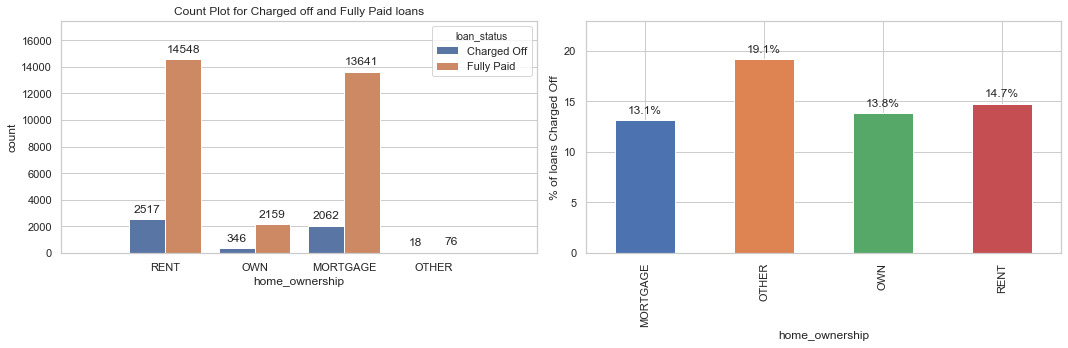

In [122]:
plt.figure(figsize=(10,5))
plot_graphs('home_ownership')

**Observation:**
* Peolple who are in **RENT** house and people are under **MORTGAGE** their property are charged off more.



**Variable - annual_inc** (The self-reported annual income provided by the borrower during registration.)

In [123]:
master_loan.annual_inc.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

count     35367.00
mean      69095.99
std       63967.05
min        4000.00
10%       30000.00
25%       41500.00
50%       60000.00
75%       82500.00
90%      115000.00
max     6000000.00
Name: annual_inc, dtype: float64

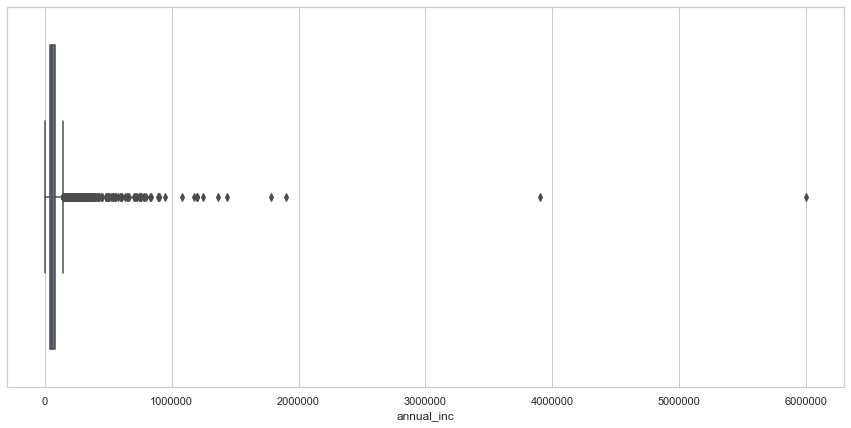

In [124]:
plt.figure(figsize=(15, 7))
sns.boxplot(x=master_loan['annual_inc'], data=master_loan)

**Observations**
* The annual income mentioned by the borrowers ranges from min of 4,000 to max of 6,000,000.
* Median annual income recorded is around 60,000. Around 90% of the people have an annual income less than 115000

In [125]:
# We can remove the outliers from the annual income. Retain only data within +3 to -3 standard deviations.
df = master_loan[np.abs(master_loan.annual_inc-master_loan.annual_inc.mean()) <= (3*master_loan.annual_inc.std())]

In [126]:
df.annual_inc.describe()

count    35122.00
mean     66255.52
std      35749.84
min       4000.00
25%      41004.00
50%      59449.00
75%      81969.00
max     260000.00
Name: annual_inc, dtype: float64

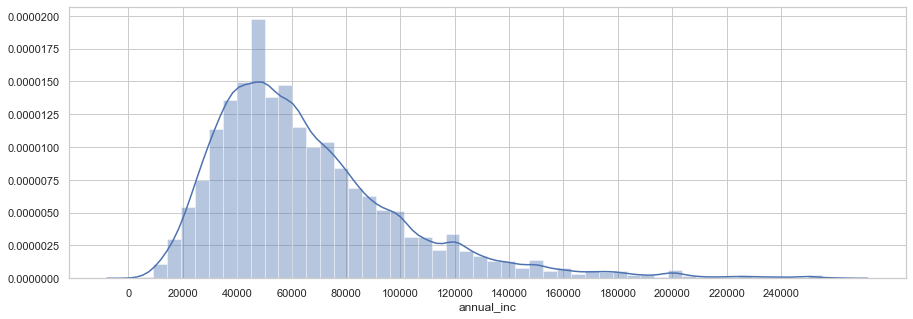

In [127]:
plt.figure(figsize=(15, 5))
sns.distplot(df['annual_inc'], hist_kws={'log':False})
plt.xticks(np.arange(0, 260000, 20000))
plt.show()

**Observation:**

10000 seems to be a good bin size to further analyze income as categories

In [128]:
#Creating Derived categorical variable
master_loan['income_bin'] = master_loan['annual_inc']/20000
master_loan['income_bin'] = master_loan['income_bin'].astype(int)

[Text(0, 0, '0-10k'),
 Text(1, 0, '10-20k'),
 Text(2, 0, '20-30k'),
 Text(3, 0, '30-40k'),
 Text(4, 0, '40-50k'),
 Text(5, 0, '50-60k'),
 Text(6, 0, '60-70k'),
 Text(7, 0, '70-80k'),
 Text(8, 0, '80-90k'),
 Text(9, 0, '90-100k'),
 Text(10, 0, '100-110k'),
 Text(11, 0, '110-120k'),
 Text(12, 0, '120-130k'),
 Text(13, 0, '130-140k'),
 Text(14, 0, '140-150k'),
 Text(15, 0, '150-160k'),
 Text(16, 0, '160-170k'),
 Text(17, 0, '170-180k'),
 Text(18, 0, '190-200k'),
 Text(19, 0, '200-210k')]

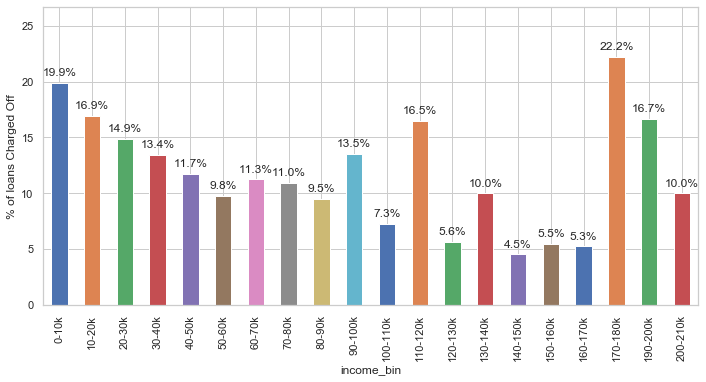

In [129]:
plt.figure(figsize=(10,5))
ax = plotLoanStatus(master_loan.loc[master_loan['income_bin']<21], 'income_bin')
ax.set_xticklabels([(str(int(x.get_text())*10)+'-'+str(int(x.get_text())*10+10)+'k') for x in ax.get_xticklabels()])

**Observation:**

* People who are early stage of their career with income in the range 0-10K charged off more, about 19.9%.
* Other interesting factor is people with income range 170-180K bin have got maximum Charged Off, about 22.2%.

**Variable - verification_status** (Indicates if income was verified by LC, not verified, or if the income source was verified)

In [130]:
master_loan.verification_status.value_counts()


Not Verified       14840
Verified           11363
Source Verified     9164
Name: verification_status, dtype: int64

Loans 'Verified' and 'Source Verified', both these status have been verified by the LC. 



<Figure size 1440x360 with 0 Axes>

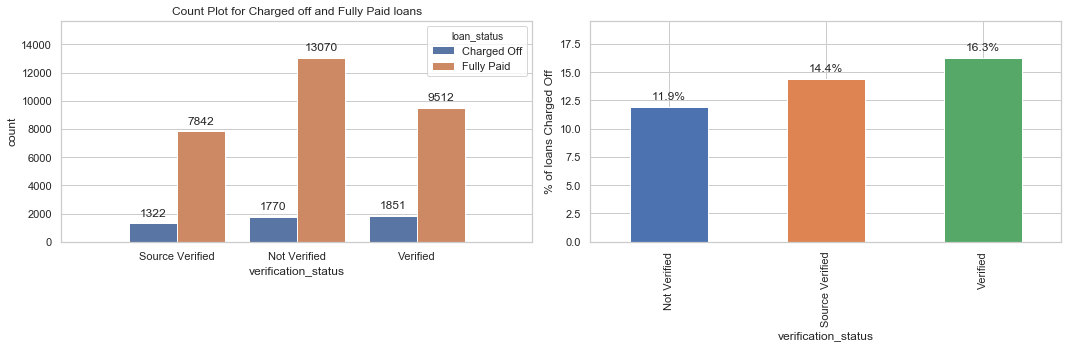

In [131]:
plt.figure(figsize=(20,5))
plot_graphs('verification_status', True)

**Observation:**

* Its evident from above graphs, that number of loans which are 'Non Verified' are higher than the 'Source Verified' and 'Verified' loans. This is matter of concern, Lending Club should ensure to verify the Borrowers source before approving loan. This is essentiall in reducing potential future defaulter percentage.

**Variable: issue_d** (The month which the loan was funded)

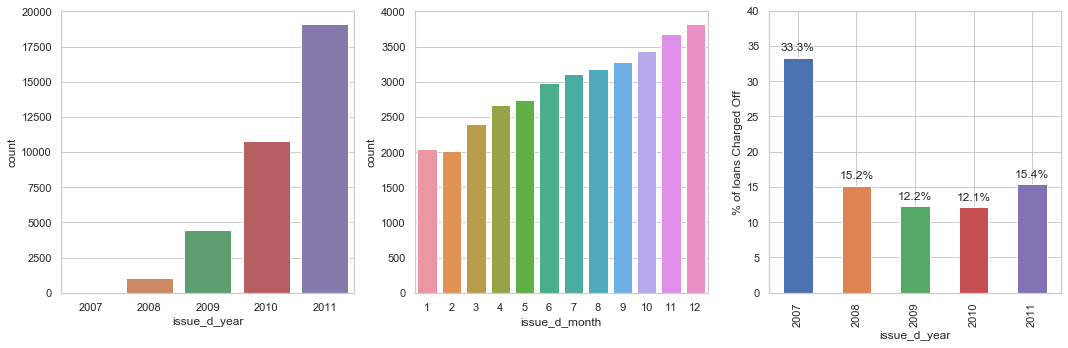

In [132]:
plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
sns.countplot(master_loan['issue_d_year'], order=sorted(master_loan.issue_d_year.unique()))

plt.subplot(1, 3, 2)
sns.countplot(master_loan['issue_d_month'], order=sorted(master_loan.issue_d_month.unique()))

#Fraction of loans charged off and fully Paid
plt.subplot(1, 3, 3)
plotLoanStatus(master_loan, 'issue_d_year')

plt.show()

**Observation:**

* We can notice LC has consistently increasing lending from 2007 onwards, we could able to see increasing trend in first graph.
* From second graph we can infer, the number of loan issued rises over the month from jan to Dec. The Jan and Feb being the lowest. The November and Dcember months seen highest loans are being issued.

<Figure size 720x360 with 0 Axes>

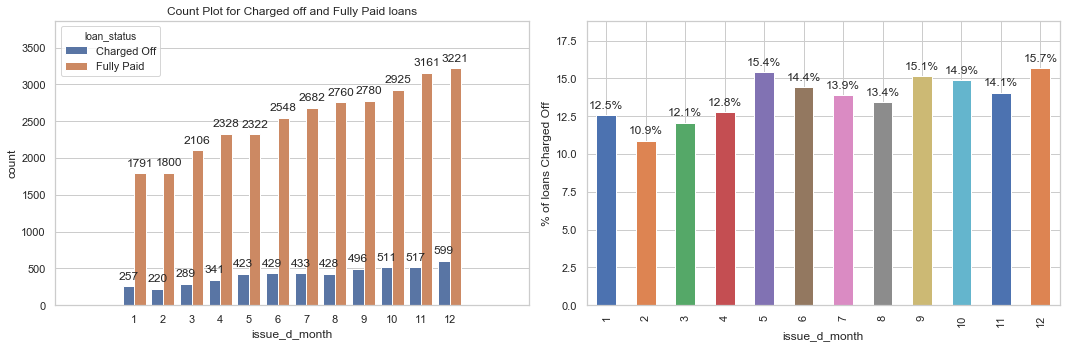

In [133]:
plt.figure(figsize=(10, 5))
plot_graphs('issue_d_month')

**Observation:**

* Month of loan is spread out and has no significant effect on likelihood of default.

**Variable - addr_state** (The state provided by the borrower in the loan application)

In [134]:
master_loan.addr_state.value_counts(normalize=True).head(10)


CA   0.18
NY   0.10
FL   0.07
TX   0.07
NJ   0.05
IL   0.04
PA   0.04
VA   0.04
GA   0.04
MA   0.03
Name: addr_state, dtype: float64

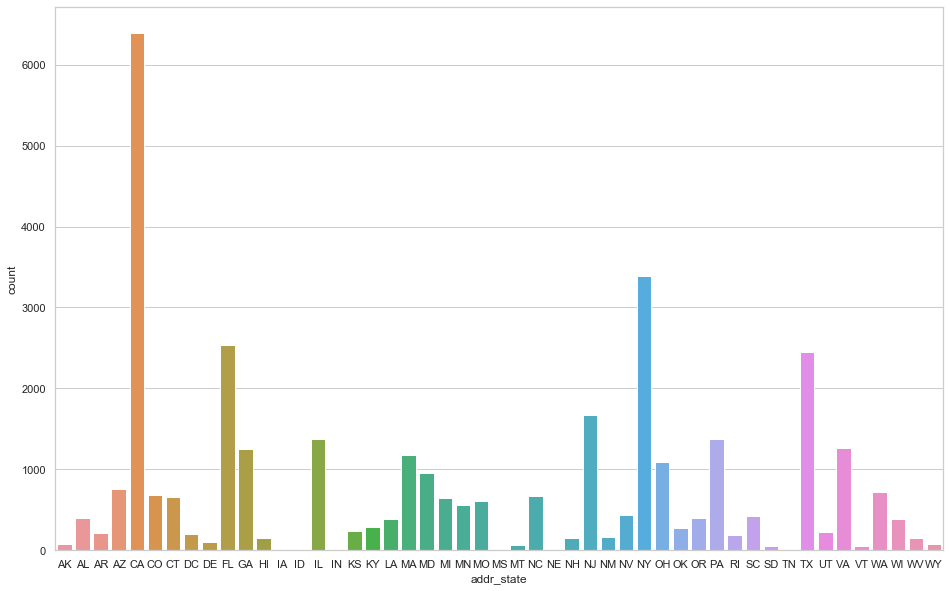

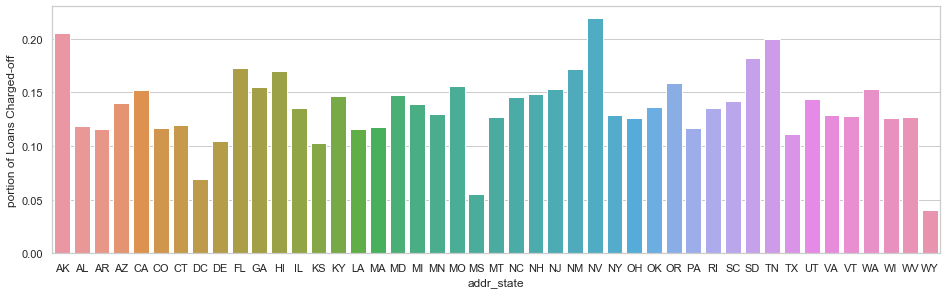

In [135]:
plt.figure(figsize=(35,10))
plt.subplot(1, 2, 1)
sns.countplot(master_loan['addr_state'], order=sorted(master_loan.addr_state.unique()))

#Fraction of loans charged off and fully Paid
charge_off_count = master_loan.groupby('addr_state')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off']  
Fully_paid_count = master_loan.groupby('addr_state')['loan_status'].value_counts(normalize=True).loc[:,'Fully Paid']  

plt.figure(figsize=(35,10))
plt.subplot(2, 2, 1)
a=sns.barplot(x=charge_off_count.index, y=charge_off_count.values)
a.set_ylabel('portion of Loans Charged-off')
#plt.subplot(1, 2, 2)
#b=sns.barplot(x=Fully_paid_count.index, y=Fully_paid_count.values)
#b.set_ylabel('portion of Loans Fully Paid')
plt.show()

#### Observation:

* Top 3 loans per state:  **California**, **New york:** and **Florida**.
* The states with higher "Charge Off" rates have very low number of loans. Hence, we confirm that this variable doesn't provide significant analysis and can be ignored.

**Variable - dti** (A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income.)

in otherwords, dti = (Borrower's total debt) /(Borrower's total income)

Lower the dti better chances of repaying, if dti is high more difficulty for repaying.

In [136]:
master_loan.dti.describe()


count   35367.00
mean       13.40
std         6.64
min         0.00
25%         8.32
50%        13.50
75%        18.64
max        29.99
Name: dti, dtype: float64

<Figure size 720x360 with 0 Axes>

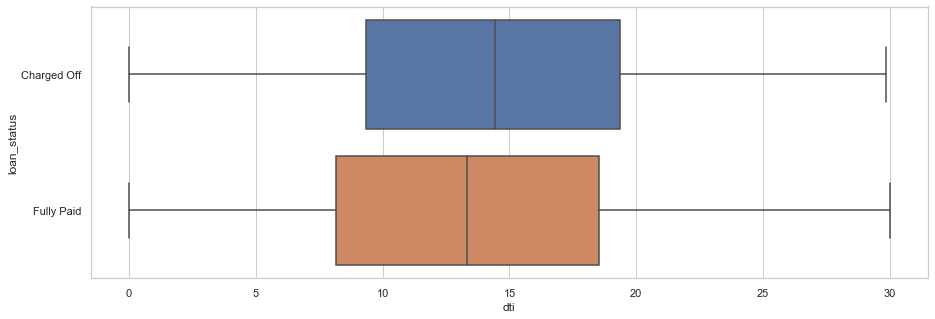

In [137]:
plt.figure(figsize=(10,5))

plot_distribution_box(master_loan, 'dti')

In [138]:
# Let's create derived variable by grouping the dti into bins. 
master_loan['dti_bin'] = pd.cut(master_loan['dti'], [0,5,10,15,20,25,30], labels=['0-5','5-10','10-15','15-20','20-25','25-30'])

<Figure size 720x360 with 0 Axes>

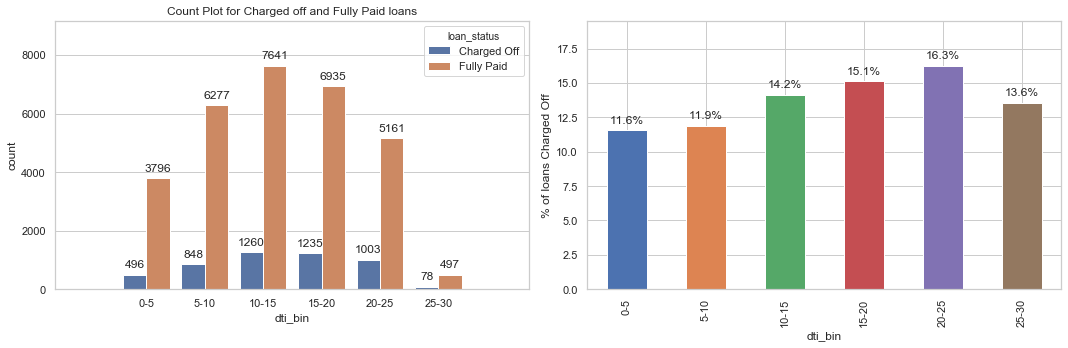

In [139]:
plt.figure(figsize=(10,5))
plot_graphs('dti_bin')

**Observation:**

* From above graph its clear, as dti increases (i.e. debt to income ratio increases) higher percentage of loans are defaulted.
* As we can see, **Higher the dti higher the chances of loan being defaulted**.

**Variable - delinq_2yrs** (The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years.)

In [140]:
master_loan.delinq_2yrs.value_counts(normalize=True)


0    0.89
1    0.08
2    0.02
3    0.01
4    0.00
5    0.00
6    0.00
7    0.00
8    0.00
11   0.00
9    0.00
Name: delinq_2yrs, dtype: float64

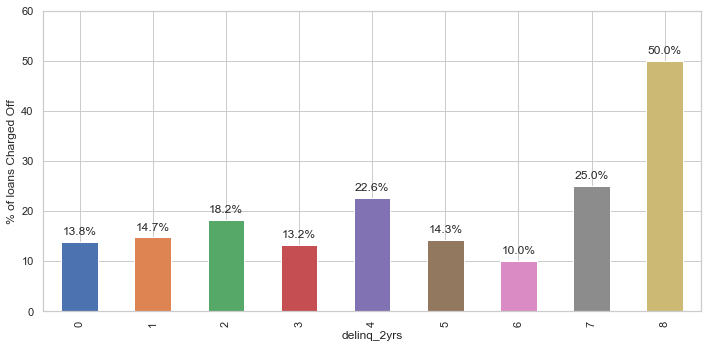

In [141]:
plt.figure(figsize=(10,5))
plotLoanStatus(master_loan, 'delinq_2yrs')

**Observation:**

* The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years values ranges between 0 and 11.
* There are higher chances of default if this variable is greater than 1.

**Variable - open_acc** (The number of open credit lines in the borrower's credit file.)

In [142]:
master_loan.open_acc.describe()

count   35367.00
mean        9.33
std         4.37
min         2.00
25%         6.00
50%         9.00
75%        12.00
max        44.00
Name: open_acc, dtype: float64

<Figure size 1080x360 with 0 Axes>

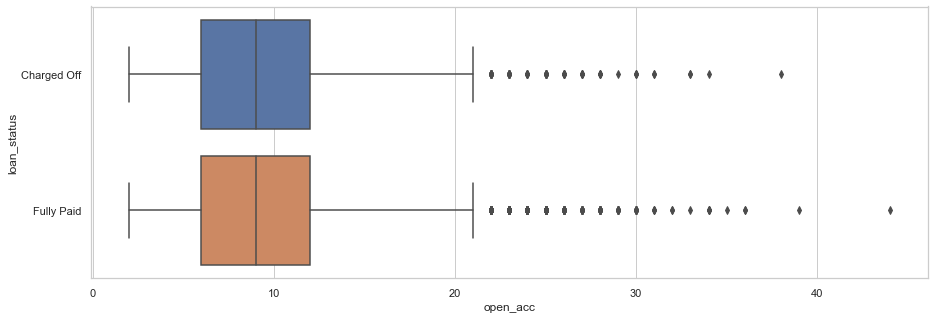

In [143]:
plt.figure(figsize=(15,5))
plot_distribution_box(master_loan, 'open_acc')
plt.show()

**Observation:**

* The median of the distribution sugests that by large the borrower's seem to have 9 open credit lines.
* There is no significant difference in the credit lines of charged off and fully paid loans.


**Variable - pub_rec** (Number of derogatory public records.)

In [144]:
master_loan.pub_rec.value_counts(normalize=True)

0   0.95
1   0.05
2   0.00
3   0.00
4   0.00
Name: pub_rec, dtype: float64

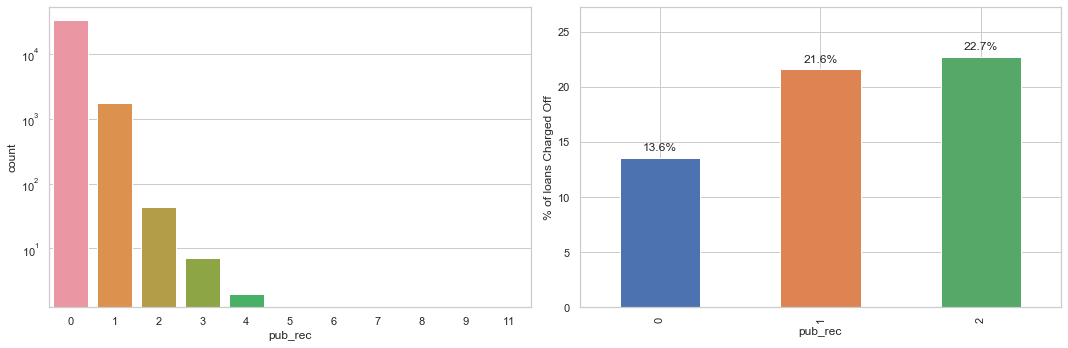

In [145]:
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
c=sns.countplot(master_loan['pub_rec'], order=sorted(master_loan.delinq_2yrs.unique()))
c.set_yscale('log')

plt.subplot(1, 2, 2)
plotLoanStatus(master_loan, 'pub_rec')
plt.show()

**Observation:**

* Most (95%) of the borrowers have no Public derogatory records. About 5% have 1 derogatory record.
* Even having 1 derogatory record substantially increases the chances of getting default.

A derogatory item is an entry that may be considered negative by lenders because it indicates risk and hurts your ability to qualify for credit or other services. Public records and collections are derogatory items because they reflect financial obligations that were not paid as agreed.

**Variable - revol_bal** (Total credit revolving balance)

In [146]:
master_loan.revol_bal.describe()

count    35367.00
mean     13367.68
std      15678.46
min          0.00
25%       3782.00
50%       8934.00
75%      17064.50
max     149588.00
Name: revol_bal, dtype: float64

The revolving bal varies from min 0 to max of 150,000. The median revol_bal is of ~9000.



In [147]:
# keep only the ones that are within +3 to -3 standard deviations in the column 'Data'.
master_loan = master_loan[np.abs(master_loan.revol_bal-master_loan.revol_bal.mean()) <= (3*master_loan.revol_bal.std())]

The values vary a lot. Transforming to a log scale will help analyse better.



In [148]:
master_loan['revol_bal_log'] = master_loan['revol_bal'].apply(lambda x : np.log(x+1))

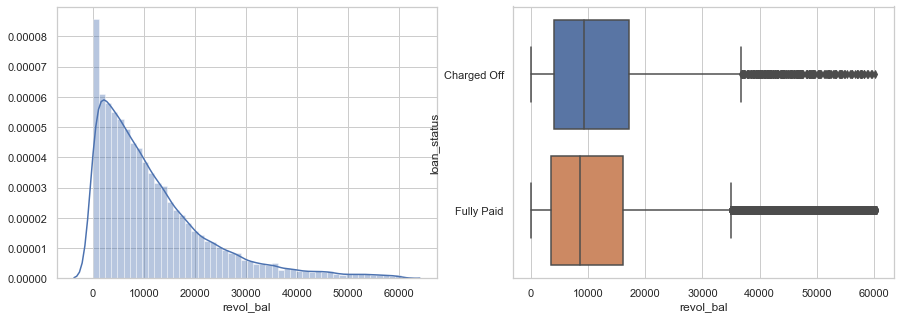

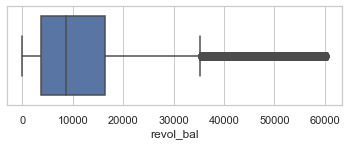

In [149]:
plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
sns.distplot(master_loan['revol_bal'])
plt.subplot(1, 2, 2)
sns.boxplot(x=master_loan['revol_bal'], y=master_loan['loan_status'], data=master_loan)
#sns.barplot(x='loan_status', y='annual_inc_log',data= master_loan)
plt.show()
plt.subplot(2, 1, 1)
sns.boxplot(x=master_loan['revol_bal'], data=master_loan)
plt.show()

In [150]:
master_loan.groupby('loan_status')['revol_bal'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,4858.00,12453.84,11330.14,0.00,4161.00,9336.50,17212.50,60071.00
Fully Paid,29739.00,11641.21,10974.61,0.00,3612.00,8581.00,16138.50,60376.00


**Observation:**

* There is no large difference in revolving balance mean for charged off an fully Paid loans

**Variable - revol_util**

Data_Dictionary:Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.

In [151]:
master_loan.revol_util.describe()

count   34597.00
mean       48.90
std        28.21
min         0.00
25%        25.60
50%        49.40
75%        72.30
max        99.90
Name: revol_util, dtype: float64

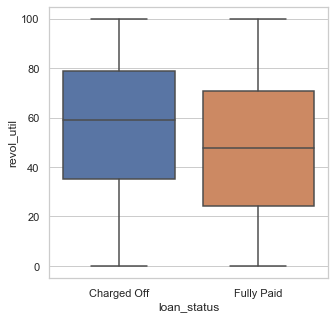

In [152]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(y=master_loan['revol_util'], x=master_loan['loan_status'], data=loan)

**Observation:**

* The average utilization rate is around 49%
* This requires more analysis.

In [153]:
master_loan['revol_util_bin'] = round(master_loan['revol_util']/5)

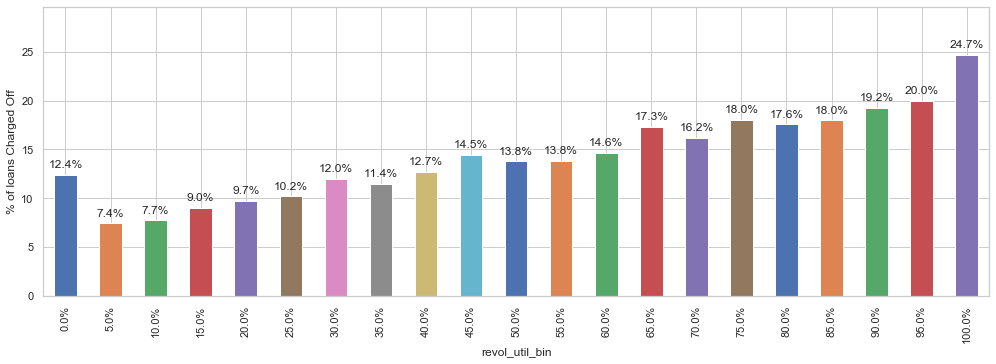

In [154]:
plt.figure(figsize=(14,5))
ax = plotLoanStatus(master_loan, 'revol_util_bin')
ax.set_xticklabels([(str(float(x.get_text())*5)+'%') for x in ax.get_xticklabels()])
plt.show()

# Bivariate Analysis

Let's analyse loan_amnt lended over years to understand the trend of lending.

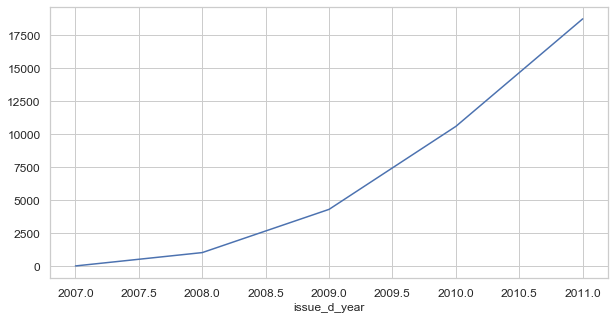

In [155]:
plt.figure(figsize=(10,5))
master_loan.groupby('issue_d_year').loan_amnt.count().plot(kind='line', fontsize=12)
plt.show()

Median lending amount over time.

**Observation:**

* We see increaing in lending over time. During 2007–2008 time frame, due to global financial crisis (GFC) the average loan amount dropped sharply.

Let's analyse **loan_amnt with annual_inc**.

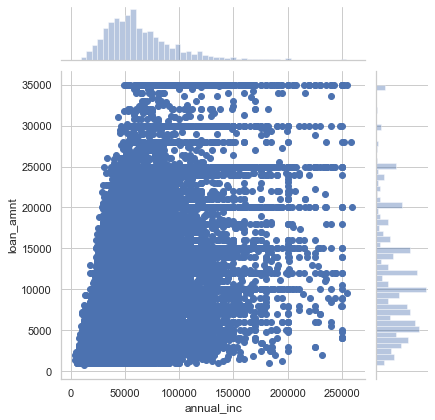

In [156]:
sns.jointplot('annual_inc', 'loan_amnt', master_loan.loc[master_loan['annual_inc']<260000])
plt.show()

**Observation:**

* As per plot we can infer that, borrowers with average income lower than 50000 are taking loans of 25000 or higher.
* These would be risky loans for LC.


Let's analyse **loan_amnt with grade**.

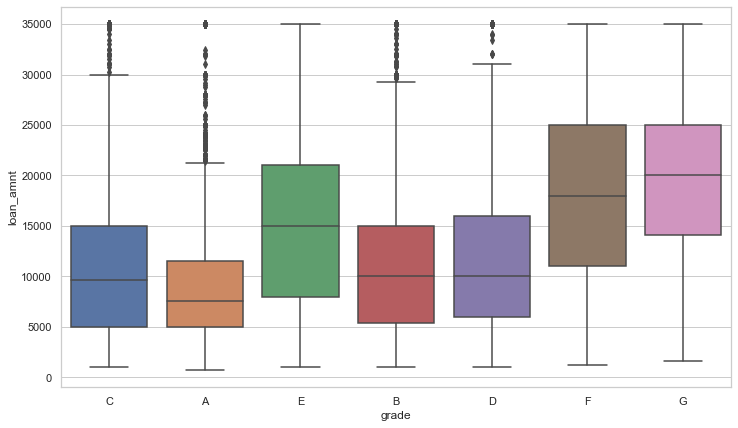

In [157]:
plt.figure(figsize=(12,7))
sns.boxplot(y=master_loan['loan_amnt'], x=master_loan['grade'], data=loan)

* From boxplot demonstrates us the distribution of loan anount across grades. Its clearly visible **higher the loan amounts are given lower grade**.  


Let's analyse **verification_status** vs **loan_amnt** vs **loan_status**.

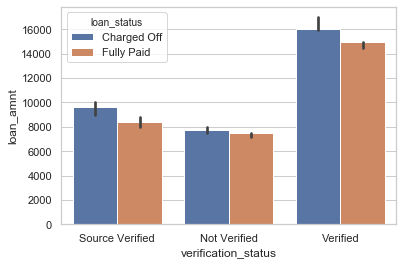

In [158]:
sns.barplot(x='verification_status', y='loan_amnt', hue="loan_status", data=master_loan, estimator=np.median)

**Observation:**
* From barplot we can infer higher value loans are verified regularly. Higher value loans carry more risk of getting default hence these loans are verified more often by Lending Club.

Let's analyse **Interest Rate with term**

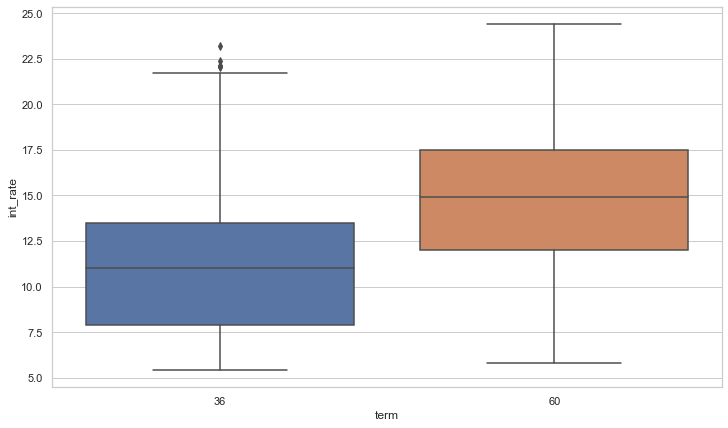

In [159]:
plt.figure(figsize=(12,7))
sns.boxplot(y=master_loan['int_rate'], x=master_loan['term'], data=loan)

**Observation:**

* Term 36 assosiated with less interest rate compared to 60 month term. 
* Higher value loans are approved with larger tenure.
* As term increases the interest rate also increased.

Let's analyse **int_rate** and **sub_grade**

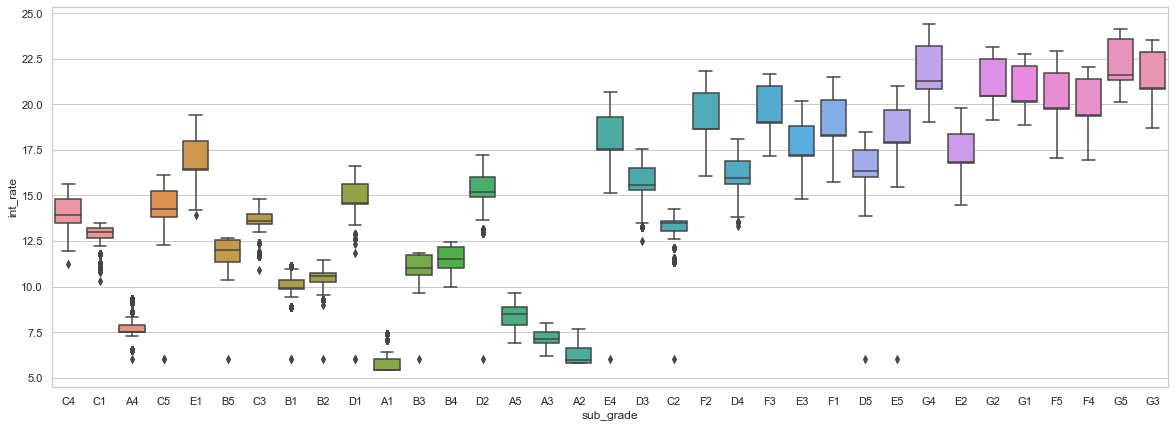

In [160]:
plt.figure(figsize=(20,7))
sns.boxplot(y=master_loan['int_rate'], x=master_loan['sub_grade'], data=loan)

**Observation:**

* From boxplot we can confirm that interest rates directly proportional to subgrade. i.e. interest rate increases sun grade also increased.
* Higher the sub grade hign is interest rate for the loan.

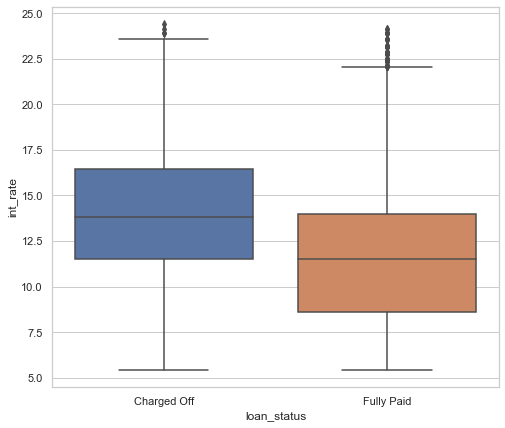

In [161]:
plt.figure(figsize=(8,7))
sns.boxplot(y=master_loan['int_rate'], x=master_loan['loan_status'], data=loan)

**Observation:**

* Loans at a higher intrest rate are more likely to be Charged Off.

Let's analyse **Loan amount vs Grade vs Term**

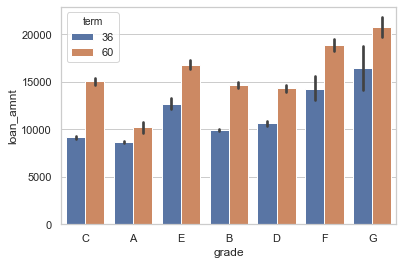

In [162]:
sns.barplot(x='grade', y='loan_amnt', hue="term", data=master_loan, estimator=np.mean)
plt.show()

**Observation:**

* We can conslude that **higher loan amounts are asoosiated with lower grade and longer term**.

### Loan amount Vs term Vs Loan Status

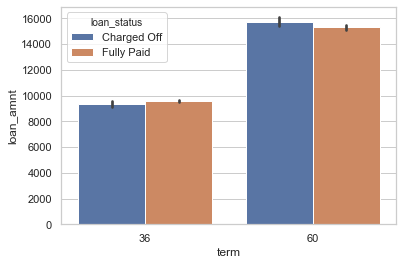

In [163]:
sns.barplot(x='term', y='loan_amnt', hue="loan_status", data=master_loan, estimator=np.mean)
plt.show()

### Observation:

* Higher loan amount are associated with longer terms and high Charge Offs.

### revol_util Vs grade Vs Loan Status

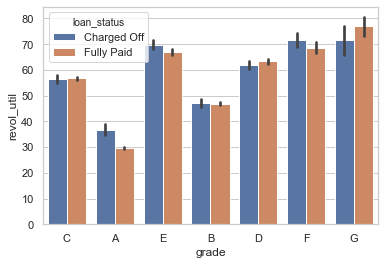

In [164]:
sns.barplot(x='grade', y='revol_util', hue="loan_status", data=master_loan, estimator=np.mean)
plt.show()

### Observation:

* revol_util and grade(and therefore int_rate) are correlated in some way. The revol_util is positivly correlated to the grade. As the grade goes from A to E the revol_util also increases. This may be because higer loan amounts are accosiated with higher grades.

### revol_util vs Grade

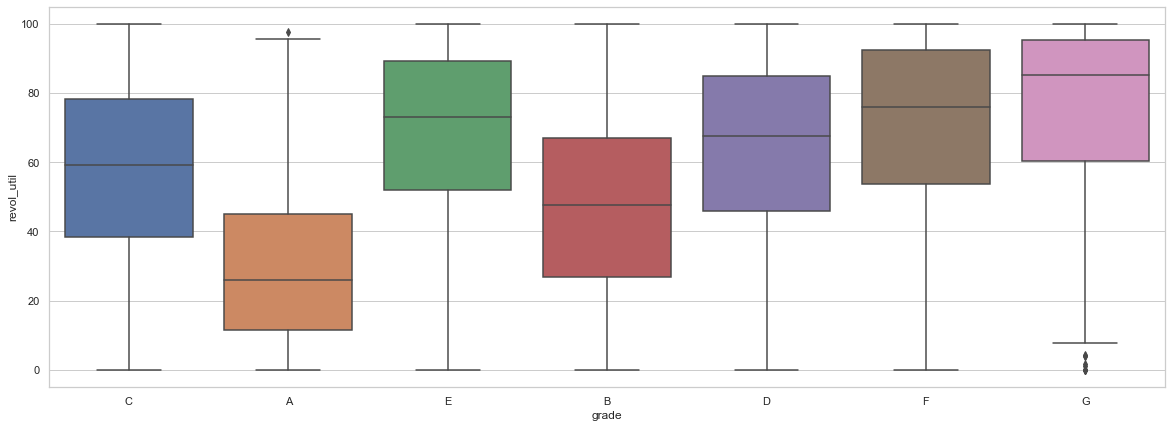

In [165]:
plt.figure(figsize=(20,7))
sns.boxplot(y=master_loan['revol_util'], x=master_loan['grade'], data=loan)

In [166]:
corr=master_loan.corr()
corr['loan_amnt']

loan_amnt                 1.00
int_rate                  0.30
installment               0.93
emp_length                0.15
annual_inc                0.25
dti                       0.06
delinq_2yrs              -0.04
open_acc                  0.17
pub_rec                  -0.04
revol_bal                 0.37
revol_util                0.06
total_pymnt               0.88
pub_rec_bankruptcies     -0.03
earliest_cr_line_month   -0.02
earliest_cr_line_year    -0.19
issue_d_month             0.05
issue_d_year              0.12
interest_rate_buckets     0.30
income_bin                0.25
revol_bal_log             0.25
revol_util_bin            0.06
Name: loan_amnt, dtype: float64

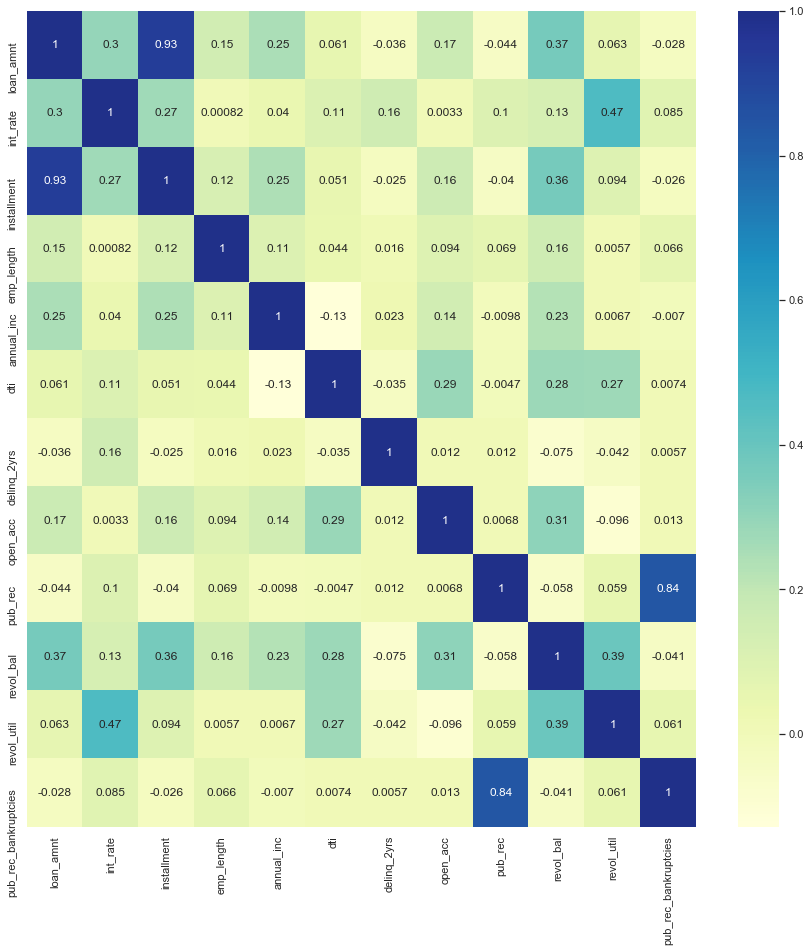

In [167]:
plt.figure(figsize=(15,15))
cont_var= ['loan_amnt', 'int_rate', 'installment',
       'emp_length', 'annual_inc',
       'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'pub_rec_bankruptcies']
corr = master_loan[cont_var].corr()
sns.heatmap(corr, annot=True, center=0.5, cmap="YlGnBu")

### Observation:

* loan_amnt is correlated with installment with factor of 93.
* pub_rec is correlated with pub_rec_bankrupcies with factor of 0.84.

### dti vs open_acc

In [168]:
master_loan['dti_bin']
master_loan.groupby('dti_bin').int_rate.mean()

dti_bin
0-5     11.10
5-10    11.59
10-15   12.05
15-20   12.39
20-25   12.63
25-30    9.57
Name: int_rate, dtype: float64

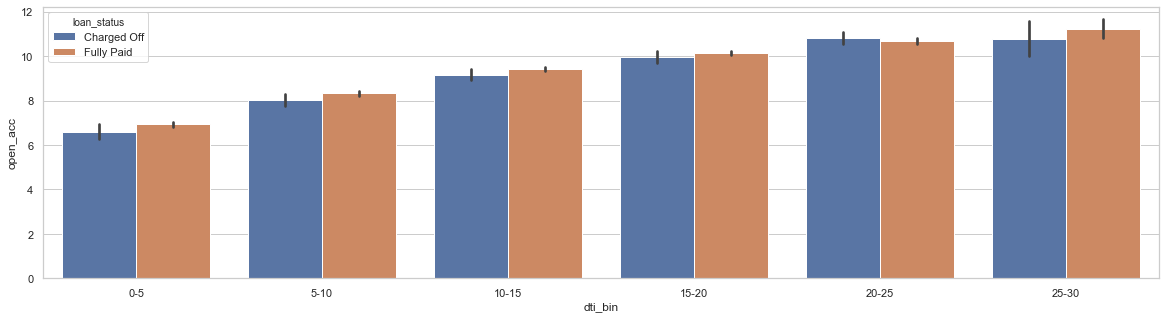

In [169]:
plt.figure(figsize=(20,5))
sns.barplot(x='dti_bin', y='open_acc', hue='loan_status',data=master_loan, estimator=np.mean)
plt.show()

### Observation:

* The dti increses with the number of open credit line in borrowers credit file.

### delinq_2yr VS int_rate VS loan_status

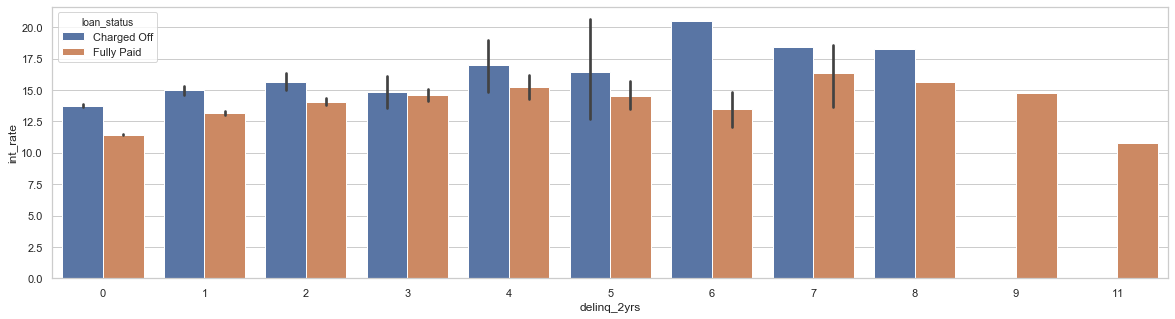

In [170]:
plt.figure(figsize=(20,5))
sns.barplot(x='delinq_2yrs', y='int_rate', hue='loan_status',data=master_loan, estimator=np.mean)
plt.show()

### Observation:

* In genral, intrest rate offered inceases with the number of deliquency of the borrower.